---
## 1. Configuración y utilidades

In [ ]:
# Instalación de dependencias (ejecutar solo una vez)
# !pip install pandas numpy matplotlib seaborn statsmodels scipy scikit-learn pydataxm holidays openpyxl

In [164]:
import os, sys, warnings, json
from pathlib import Path
from datetime import date, datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'semibold'

print('pandas', pd.__version__, '| numpy', np.__version__)

pandas 2.3.3 | numpy 2.5.1


In [165]:
# ---- Rutas del proyecto ----
# DIR_RAW apunta directamente a la carpeta OneDrive donde viven los CSV/Excel descargados.
# Cache y salidas se guardan junto al notebook (no en OneDrive, para no sincronizar
# archivos pesados de cache en cada corrida).
BASE      = Path('.').resolve()
DIR_RAW   = Path(r'C:\Users\andre\OneDrive\cosas de la universidad\Uniandes\VIII\Tesis\data')
DIR_CACHE = BASE / 'cache_api'        # Cache de descargas vía pydataxm
DIR_OUT   = BASE / 'salidas'          # Figuras y tablas generadas

if not DIR_RAW.exists():
    raise FileNotFoundError(
        f'No se encontro la carpeta de datos: {DIR_RAW}. '
        'Verifica que OneDrive este sincronizado o ajusta la ruta manualmente.'
    )

for d in (DIR_CACHE, DIR_OUT):
    d.mkdir(exist_ok=True, parents=True)

# ---- Periodo de estudio ----
FECHA_INI = date(2015, 1, 1)
FECHA_FIN = date(2025, 12, 31)

print(f'Periodo de estudio: {FECHA_INI} a {FECHA_FIN}')
print(f'Datos crudos en:    {DIR_RAW}')

Periodo de estudio: 2015-01-01 a 2025-12-31
Datos crudos en:    C:\Users\andre\OneDrive\cosas de la universidad\Uniandes\VIII\Tesis\data


In [166]:
# ---- Utilidades ----

def horas_a_largo(df, nombre_valor, col_fecha='Date'):
    """Convierte el formato ancho de XM (Values_Hour01..Hour24) a formato largo
    con un timestamp horario. Devuelve DataFrame [datetime, nombre_valor]."""
    cols_h = [c for c in df.columns if c.lower().startswith('values_hour')]
    if not cols_h:
        raise ValueError('No se encontraron columnas Values_HourXX')
    d = df[[col_fecha] + cols_h].copy()
    d[col_fecha] = pd.to_datetime(d[col_fecha])
    largo = d.melt(id_vars=col_fecha, value_vars=cols_h,
                   var_name='hora_str', value_name=nombre_valor)
    largo['hora'] = largo['hora_str'].str.extract(r'(\d+)').astype(int) - 1
    largo['datetime'] = largo[col_fecha] + pd.to_timedelta(largo['hora'], unit='h')
    return largo[['datetime', nombre_valor]].sort_values('datetime').reset_index(drop=True)


def resumen_serie(s, nombre=None):
    """Estadísticos descriptivos robustos de una serie."""
    s = pd.Series(s).dropna()
    nombre = nombre or s.name or 'serie'
    q = s.quantile([.01, .05, .25, .5, .75, .95, .99])
    return pd.Series({
        'n': len(s), 'media': s.mean(), 'desv_est': s.std(),
        'cv': s.std() / s.mean() if s.mean() else np.nan,
        'min': s.min(), 'p01': q[.01], 'p05': q[.05], 'q1': q[.25],
        'mediana': q[.5], 'q3': q[.75], 'p95': q[.95], 'p99': q[.99],
        'max': s.max(), 'rango_iq': q[.75] - q[.25],
        'asimetria': s.skew(), 'curtosis': s.kurtosis(),
    }, name=nombre)


def tabla_resumen(df, cols=None):
    cols = cols or df.select_dtypes(include=[np.number]).columns
    return pd.DataFrame([resumen_serie(df[c], c) for c in cols])


def guardar_fig(nombre):
    plt.tight_layout()
    plt.savefig(DIR_OUT / f'{nombre}.png', dpi=150, bbox_inches='tight')


def marcar_faltantes(df, col_fecha='fecha', freq='D'):
    """Reporta días/horas ausentes en el rango observado."""
    f = pd.to_datetime(df[col_fecha])
    completo = pd.date_range(f.min(), f.max(), freq=freq)
    faltan = completo.difference(f)
    return pd.DataFrame({'esperados': [len(completo)], 'observados': [f.nunique()],
                         'faltantes': [len(faltan)],
                         'pct_faltante': [100 * len(faltan) / len(completo)]}), faltan

print('Utilidades cargadas.')

Utilidades cargadas.


---
## 2. Carga de datos locales



In [167]:
# ---- Series horarias (formato ancho) ----
ARCHIVOS_HORARIOS = {
    'precio_bolsa':      ('PrecBolsNaci_Sistema.csv', 'COP/kWh'),
    'demanda_comercial': ('DemaCome_Sistema.csv',     'kWh'),
    'generacion':        ('Gene_Sistema.csv',         'kWh'),
}

horarias = {}
for var, (archivo, unidad) in ARCHIVOS_HORARIOS.items():
    ruta = DIR_RAW / archivo
    if not ruta.exists():
        print(f'  [FALTA] {archivo}')
        continue
    crudo = pd.read_csv(ruta)
    horarias[var] = horas_a_largo(crudo, var)
    print(f'  [OK] {var:<20} {len(horarias[var]):>7,} registros · {unidad}')

print()
for var, d in horarias.items():
    print(f'{var}: {d.datetime.min()} → {d.datetime.max()}')

  [OK] precio_bolsa          96,432 registros · COP/kWh
  [OK] demanda_comercial     96,432 registros · kWh
  [OK] generacion            96,432 registros · kWh

precio_bolsa: 2015-01-01 00:00:00 → 2025-12-31 23:00:00
demanda_comercial: 2015-01-01 00:00:00 → 2025-12-31 23:00:00
generacion: 2015-01-01 00:00:00 → 2025-12-31 23:00:00


In [168]:
# ---- Series diarias (formato largo) ----
ARCHIVOS_DIARIOS = {
    'aportes_energia':  ('AporEner_Sistema.csv',        'kWh'),
    'volumen_util':     ('VoluUtilDiarEner_Sistema.csv','kWh'),
    'capacidad_util':   ('CapaUtilDiarEner_Sistema.csv','kWh'),
}

diarias = {}
for var, (archivo, unidad) in ARCHIVOS_DIARIOS.items():
    ruta = DIR_RAW / archivo
    if not ruta.exists():
        print(f'  [FALTA] {archivo}')
        continue
    d = pd.read_csv(ruta)
    d['fecha'] = pd.to_datetime(d['Date'])
    diarias[var] = d[['fecha', 'Value']].rename(columns={'Value': var}).sort_values('fecha')
    print(f'  [OK] {var:<20} {len(diarias[var]):>7,} registros · {unidad}')

  [OK] aportes_energia        4,018 registros · kWh
  [OK] volumen_util           4,018 registros · kWh
  [OK] capacidad_util         4,018 registros · kWh


In [169]:
# ---- Índice ONI (ENSO) ----
ruta_oni = DIR_RAW / 'oni_noaa.csv'
if ruta_oni.exists():
    oni = pd.read_csv(ruta_oni)
    oni['fecha'] = pd.to_datetime(oni['Date'])
    oni = oni[['fecha', 'oni']].sort_values('fecha')

    # Clasificación estándar NOAA: |ONI| >= 0.5 durante 5 trimestres consecutivos
    def clasificar_enso(v):
        if v >= 1.5:   return 'El Nino fuerte'
        if v >= 0.5:   return 'El Nino'
        if v <= -1.5:  return 'La Nina fuerte'
        if v <= -0.5:  return 'La Nina'
        return 'Neutral'

    oni['regimen_enso'] = oni['oni'].apply(clasificar_enso)
    print(oni[(oni.fecha >= '2015-01-01')].regimen_enso.value_counts())
    display(oni.tail(3))
else:
    oni = None
    print('[FALTA] oni_noaa.csv')

regimen_enso
Neutral           58
La Nina           34
El Nino           32
El Nino fuerte    14
Name: count, dtype: int64


,fecha,oni,regimen_enso
915,2026-04-01,0.460,Neutral
916,2026-05-01,0.950,El Nino
917,2026-06-01,1.390,El Nino


---
## 3. Descarga de variables adicionales (API XM)



In [170]:
# ---- Catálogo de variables priorizadas ----
# Columnas: (MetricId, Entity, granularidad, grupo, temporalidad)
# temporalidad: 'ex_ante' | 'contemporanea' | 'ex_post' | 'estructural'

CATALOGO = {
    # ===== GRUPO A — EX-ANTE (conocidas antes del día D) =====
    'costo_marginal_prog':   ('CostoMargDesp',  'Sistema', 'Horaria', 'oferta',     'ex_ante'),
    'precio_oferta_desp':    ('PrecOferDesp',   'Recurso', 'Horaria', 'oferta',     'ex_ante'),
    'max_precio_oferta':     ('MaxPrecOferNal', 'Sistema', 'Horaria', 'oferta',     'ex_ante'),
    'disp_declarada':        ('DispoDeclarada', 'Recurso', 'Horaria', 'oferta',     'ex_ante'),
    'disp_real':             ('DispoReal',      'Recurso', 'Horaria', 'oferta',     'ex_ante'),
    'disp_comercial':        ('DispoComercial', 'Recurso', 'Horaria', 'oferta',     'ex_ante'),
    'gen_programada':        ('GeneProgDesp',   'Recurso', 'Horaria', 'oferta',     'ex_ante'),
    'capacidad_efectiva':    ('CapEfecNeta',    'Recurso', 'Diaria',  'estructura', 'estructural'),
    'precio_escasez_act':    ('PrecEscaAct',    'Sistema', 'Diaria',  'escasez',    'ex_ante'),
    'precio_escasez':        ('PrecEsca',       'Sistema', 'Diaria',  'escasez',    'ex_ante'),
    'precio_marg_escasez':   ('PrecMargEsca',   'Sistema', 'Diaria',  'escasez',    'ex_ante'),
    'enficc':                ('ENFICC',         'Sistema', 'Diaria',  'confiab',    'ex_ante'),
    'recurso_marginal':      ('IndicRecurMarg', 'Recurso', 'Horaria', 'oferta',     'ex_ante'),

    # ===== GRUPO B — ESTADO DEL SISTEMA (usar rezagadas) =====
    'aportes_media_hist':    ('AporEnerMediHist','Sistema','Diaria',  'hidrologia', 'contemporanea'),
    'vertimientos':          ('VertiEner',      'Sistema', 'Diaria',  'hidrologia', 'contemporanea'),
    'emisiones_co2_kwh':     ('EmisionesCO2Eq', 'Sistema', 'Horaria', 'generacion', 'contemporanea'),
    'consumo_combustible':   ('ConsCombustibleMBTU','Recurso','Horaria','generacion','contemporanea'),
    'gen_por_recurso':       ('Gene',           'Recurso', 'Horaria', 'generacion', 'contemporanea'),
    'gen_fuera_merito':      ('GeneFueraMerito','Recurso', 'Horaria', 'generacion', 'contemporanea'),
    'gen_seguridad':         ('GeneSeguridad',  'Recurso', 'Horaria', 'generacion', 'contemporanea'),
    'demanda_no_atendida':   ('DemaNoAtenProg', 'Area',    'Diaria',  'demanda',    'contemporanea'),

    # ===== GRUPO REGIONAL =====
    'aportes_por_rio':       ('AporEner',       'Rio',     'Diaria',  'regional',   'contemporanea'),
    'volumen_por_embalse':   ('VoluUtilDiarEner','Embalse','Diaria',  'regional',   'contemporanea'),
    'capacidad_por_embalse': ('CapaUtilDiarEner','Embalse','Diaria',  'regional',   'contemporanea'),
    'demanda_por_or':        ('DemaOR',         'Agente',  'Horaria', 'regional',   'contemporanea'),

    # ===== GRUPO D — CAPA ECONÓMICA =====
    'compras_contrato':      ('CompContEner',   'Sistema', 'Horaria', 'economica',  'contemporanea'),
    'precio_prom_contrato':  ('PrecPromContRegu','Sistema','Horaria', 'economica',  'contemporanea'),
    'precio_cont_no_regu':   ('PrecPromContNoRegu','Sistema','Horaria','economica', 'contemporanea'),

    # ===== CONTEXTO =====
    'restricciones':         ('RestAliv',       'Sistema', 'Horaria', 'contexto',   'ex_post'),
    'importaciones':         ('ImpoEner',       'Sistema', 'Horaria', 'contexto',   'contemporanea'),
    'exportaciones':         ('ExpoEner',       'Sistema', 'Horaria', 'contexto',   'contemporanea'),
}

catalogo_df = pd.DataFrame(
    [(k,) + v for k, v in CATALOGO.items()],
    columns=['variable', 'metric_id', 'entity', 'granularidad', 'grupo', 'temporalidad']
)
print(f'{len(catalogo_df)} variables catalogadas\n')
display(catalogo_df.groupby(['grupo', 'temporalidad']).size().unstack(fill_value=0))

32 variables catalogadas



temporalidad,contemporanea,estructural,ex_ante,ex_post
grupo,,,,
confiab,0,0,1,0
contexto,2,0,0,1
demanda,1,0,0,0
economica,3,0,0,0
escasez,0,0,3,0
estructura,0,1,0,0
generacion,5,0,0,0
hidrologia,2,0,0,0
oferta,0,0,8,0


**Antes de descargar: verificar los MetricId reales contra el catálogo de la API.**

Los nombres de `MetricId` en el diccionario `CATALOGO` de arriba son una hipótesis razonable basada en la nomenclatura de XM, pero no todos coinciden exactamente (p. ej. `CostoMargDesp`, `PrecMargEsca`, `VertiEner`, `EmisionesCO2Eq` fallaron en una corrida real). `pydataxm` expone `get_collections()`, que trae el catálogo oficial completo — se usa aquí para corregir el diccionario con certeza en vez de adivinar.

In [ ]:
# ---- Inicializacion de la API XM (pydataxm) ----
import time
api = None
API_DISPONIBLE = False
for intento in range(1, 4):
    try:
        from pydataxm.pydataxm import ReadDB
        api = ReadDB()
        API_DISPONIBLE = True
        print('pydataxm cargado correctamente.')
        break
    except Exception as e:
        print(f'Intento {intento}/3 fallo: {str(e)[:80]}')
        time.sleep(5)
if not API_DISPONIBLE:
    print('Sin conexion a la API. Se usara solo el cache local (cache_api/).')

In [172]:
# ---- Verificación del catálogo real de métricas ----
if API_DISPONIBLE:
    try:
        colecciones = api.get_collections()
        colecciones.to_parquet(DIR_CACHE / 'catalogo_metricas.parquet')
        print(f'{len(colecciones)} métricas en el catálogo oficial de la API XM')
        display(colecciones.head(3))
    except Exception as e:
        colecciones = None
        print(f'No se pudo obtener el catálogo: {e}')
else:
    # Si ya se descargó antes, se lee del cache
    ruta_cat = DIR_CACHE / 'catalogo_metricas.parquet'
    colecciones = pd.read_parquet(ruta_cat) if ruta_cat.exists() else None

if colecciones is not None:
    # Detectar la columna que contiene el MetricId (el nombre exacto varía entre
    # versiones de la librería, por eso se busca por patrón en vez de asumir)
    col_metric = [c for c in colecciones.columns if 'metric' in c.lower() and 'id' in c.lower()]
    col_metric = col_metric[0] if col_metric else colecciones.columns[0]
    col_nombre = [c for c in colecciones.columns if 'name' in c.lower() or 'nombre' in c.lower()]
    col_nombre = col_nombre[0] if col_nombre else col_metric

    ids_validos = set(colecciones[col_metric].astype(str))

    print(f'\n=== VALIDACIÓN DE CATALOGO (nuestro diccionario) ===\n')
    faltan = []
    for var, (mid, ent, *_ ) in CATALOGO.items():
        estado = 'OK' if mid in ids_validos else 'NO EXISTE'
        if estado == 'NO EXISTE':
            faltan.append((var, mid))
        print(f'  [{estado:<9}] {var:<24} MetricId={mid}')

    if faltan:
        print(f'\n{len(faltan)} MetricId inválidos. Buscando sugerencias por palabra clave...\n')
        for var, mid_malo in faltan:
            # Se buscan coincidencias parciales en el nombre descriptivo de la métrica
            palabra = var.split('_')[0]
            candidatos = colecciones[colecciones[col_nombre].astype(str).str.contains(
                palabra, case=False, na=False)]
            print(f'--- {var} (probé "{mid_malo}") ---')
            if len(candidatos):
                display(candidatos[[col_metric, col_nombre]].head(5))
            else:
                print('   Sin coincidencias automáticas — buscar manualmente en `colecciones`.')
    else:
        print('\nTodos los MetricId del catálogo son válidos.')
else:
    print('Sin conexión a la API: no se pudo validar. Se intentará descargar de todas '
          'formas; los errores se reportarán variable por variable.')


=== VALIDACIÓN DE CATALOGO (nuestro diccionario) ===

  [NO EXISTE] costo_marginal_prog      MetricId=CostoMargDesp
  [OK       ] precio_oferta_desp       MetricId=PrecOferDesp
  [OK       ] max_precio_oferta        MetricId=MaxPrecOferNal
  [OK       ] disp_declarada           MetricId=DispoDeclarada
  [OK       ] disp_real                MetricId=DispoReal
  [NO EXISTE] disp_comercial           MetricId=DispoComercial
  [OK       ] gen_programada           MetricId=GeneProgDesp
  [OK       ] capacidad_efectiva       MetricId=CapEfecNeta
  [OK       ] precio_escasez_act       MetricId=PrecEscaAct
  [OK       ] precio_escasez           MetricId=PrecEsca
  [NO EXISTE] precio_marg_escasez      MetricId=PrecMargEsca
  [OK       ] enficc                   MetricId=ENFICC
  [NO EXISTE] recurso_marginal         MetricId=IndicRecurMarg
  [OK       ] aportes_media_hist       MetricId=AporEnerMediHist
  [NO EXISTE] vertimientos             MetricId=VertiEner
  [OK       ] emisiones_co2_kwh    

,MetricId,MetricName
93,CostMargDesp,Costo Marginal Despacho Programado por Sistema
95,CostRecPos,Costo Unitario Reconciliacion Positiva por Area
96,CostRecPos,Costo Unitario Reconciliacion Positiva por Sub...
97,CostRecNeg,Costo Unitario Reconciliacion Negativa por Area
98,CostRecNeg,Costo Unitario Reconciliacion Negativa por Sub...


--- disp_comercial (probé "DispoComercial") ---


,MetricId,MetricName
40,DispoReal,Disponibilidad Real por Recurso
41,DispoCome,Disponibilidad Comercial por Recurso
42,DispoDeclarada,Disponibilidad Declarada por Recurso


--- precio_marg_escasez (probé "PrecMargEsca") ---


...

,MetricId,MetricName
8,ConsCombustibleMBTU,Consumo Combustible MBTU por Recurso
10,Gene,Generación por Recurso
11,IndRecMargina,Indicador Recurso Margina por Recurso
13,PrecOferDesp,Precio de Oferta de Despacho por Recurso
21,GeneIdea,Generación Ideal por Recurso


--- vertimientos (probé "VertiEner") ---


,MetricId,MetricName
151,VertMasa,Vertimientos Volumen por Embalse
155,VertEner,Vertimientos Energía por Embalse
156,VertEner,Vertimientos Energía por Sistema


--- aportes_pct_rio (probé "AporEnerPorc") ---


,MetricId,MetricName
120,AporEner,Aportes Energía por Sistema
131,AporEnerMediHist,Aportes Media Histórica Energía por Sistema
141,AporEner,Aportes Energía por Rio
142,AporEnerMediHist,Aportes Media Histórica Energía por Rio
152,AporCaudal,Aportes Caudal por Rio


In [ ]:
# ---- Funciones de descarga con cache y reintentos ----
import re, time

def a_numerico(df):
    if df is None:
        return None
    cols = [c for c in df.columns if re.fullmatch(r'values?(_hour\d+)?', c, flags=re.I)]
    df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')
    return df


def descargar(variable, metric_id, entity, ini=FECHA_INI, fin=FECHA_FIN,
              forzar=False, reintentos=3, espera=10):
    destino = DIR_CACHE / f'{variable}.parquet'
    if destino.exists() and not forzar:
        return a_numerico(pd.read_parquet(destino))
    if not API_DISPONIBLE:
        print(f'  [SIN API] {variable}')
        return None
    for intento in range(1, reintentos + 1):
        try:
            df = api.request_data(metric_id, entity, ini, fin)
            if df is None or len(df) == 0:
                print(f'  [VACIO] {variable}')
                return None
            df.to_parquet(destino, index=False)
            print(f'  [OK] {variable:<24} {len(df):>8,} filas')
            return a_numerico(df)
        except Exception as e:
            if intento < reintentos:
                print(f'  [REINTENTO {intento}/{reintentos}] {variable}: {str(e)[:60]}')
                time.sleep(espera)
            else:
                print(f'  [ERROR] {variable}: {str(e)[:90]}')
                return None


descargados = {}

In [174]:
# ============================================================
#  CORRECCIÓN AUTOMÁTICA DE MetricId  (contra el catálogo real)
# ============================================================
import unicodedata, re

# --- Catálogo real (ya debería existir de la celda de validación) ---
if 'colecciones' not in dir() or colecciones is None:
    colecciones = api.get_collections()
    colecciones.to_parquet(DIR_CACHE / 'catalogo_metricas.parquet')

col_metric = [c for c in colecciones.columns if 'metric' in c.lower() and 'id' in c.lower()][0]
col_entity = [c for c in colecciones.columns if c.lower() == 'entity']
col_entity = col_entity[0] if col_entity else None
col_nombre = [c for c in colecciones.columns if c not in (col_metric, col_entity)]
col_nombre = col_nombre[0] if col_nombre else col_metric

print(f'Catálogo: {len(colecciones)} entradas | id="{col_metric}" '
      f'entity="{col_entity}" nombre="{col_nombre}"\n')


def normalizar(s):
    """Quita tildes, pasa a minúscula, deja solo letras y espacios."""
    s = unicodedata.normalize('NFKD', str(s)).encode('ascii', 'ignore').decode()
    return re.sub(r'[^a-z ]', ' ', s.lower())


# Palabras clave por variable, para buscar en el nombre descriptivo del catálogo
CLAVES = {
    'costo_marginal_prog':  ['costo marginal', 'marginal despacho'],
    'precio_marg_escasez':  ['marginal escasez', 'escasez marginal'],
    'vertimientos':         ['vertimiento'],
    'emisiones_co2_kwh':    ['factor de emision', 'co eq', 'emisiones de co'],
    'precio_oferta_desp':   ['precio de oferta del despacho', 'oferta despacho'],
    'disp_declarada':       ['disponibilidad declarada'],
    'disp_real':            ['disponibilidad real'],
    'disp_comercial':       ['disponibilidad comercial'],
    'gen_programada':       ['generacion programada despacho'],
    'recurso_marginal':     ['recurso marginal', 'indicador recurso'],
    'capacidad_efectiva':   ['listado de recursos', 'capacidad efectiva'],
    'enficc':               ['energia firme', 'obligaciones de energia firme', 'enficc'],
    'gen_por_recurso':      ['generacion real por recurso', 'generacion real'],
    'gen_fuera_merito':     ['fuera de merito'],
    'gen_seguridad':        ['generacion de seguridad'],
    'consumo_combustible':  ['consumo de combustible'],
    'demanda_no_atendida':  ['demanda no atendida programada'],
    'demanda_por_or':       ['demanda por operador'],
    'aportes_por_rio':      ['aportes diarios por rio'],
    'aportes_media_hist':   ['media historica de aportes del sin'],
    'volumen_por_embalse':  ['volumen util diario por embalse'],
    'capacidad_por_embalse':['capacidad util por embalse'],
    'compras_contrato':     ['compras en contrato energia'],
    'precio_cont_no_regu':  ['precio promedio contratos no regulado'],
    'restricciones':        ['restricciones aliviadas'],
    'importaciones':        ['importaciones en energia'],
    'exportaciones':        ['exportaciones en energia'],
}

cat_norm = colecciones.copy()
cat_norm['_nombre_norm'] = cat_norm[col_nombre].apply(normalizar)
ids_validos = set(colecciones[col_metric].astype(str))

correcciones = {}
sin_match = []

print('=== BÚSQUEDA DE MetricId CORRECTOS ===\n')
for var, (mid, ent, *resto) in CATALOGO.items():
    if mid in ids_validos:
        continue  # ya es válido

    claves = CLAVES.get(var, [var.replace('_', ' ')])
    encontrado = None
    for clave in claves:
        hits = cat_norm[cat_norm['_nombre_norm'].str.contains(normalizar(clave), na=False)]
        if col_entity:  # preferir la entidad que pedimos
            pref = hits[hits[col_entity].astype(str).str.lower() == str(ent).lower()]
            if len(pref):
                hits = pref
        if len(hits):
            encontrado = hits.iloc[0]
            break

    if encontrado is not None:
        nuevo_id = str(encontrado[col_metric])
        nueva_ent = str(encontrado[col_entity]) if col_entity else ent
        correcciones[var] = (nuevo_id, nueva_ent)
        print(f'  [CORREGIDO] {var:<24} {mid:<18} → {nuevo_id:<18} (Entity={nueva_ent})')
    else:
        sin_match.append((var, mid))
        print(f'  [SIN MATCH ] {var:<24} {mid}')

# Aplicar correcciones al diccionario
for var, (nuevo_id, nueva_ent) in correcciones.items():
    _, _, *resto = CATALOGO[var]
    CATALOGO[var] = (nuevo_id, nueva_ent, *resto)

print(f'\n{len(correcciones)} corregidos | {len(sin_match)} sin coincidencia automática')

if sin_match:
    print('\nPara los sin match, buscar manualmente. Ejemplo:')
    print(">>> colecciones[colecciones[col_nombre].str.contains('palabra', case=False, na=False)]")

Catálogo: 193 entradas | id="MetricId" entity="Entity" nombre="MetricName"

=== BÚSQUEDA DE MetricId CORRECTOS ===

  [CORREGIDO] costo_marginal_prog      CostoMargDesp      → CostMargDesp       (Entity=Sistema)
  [CORREGIDO] disp_comercial           DispoComercial     → DispoCome          (Entity=Recurso)
  [CORREGIDO] precio_marg_escasez      PrecMargEsca       → PrecEscaMarg       (Entity=Sistema)
  [CORREGIDO] recurso_marginal         IndicRecurMarg     → IndRecMargina      (Entity=Recurso)
  [CORREGIDO] vertimientos             VertiEner          → VertEner           (Entity=Sistema)
  [SIN MATCH ] aportes_pct_rio          AporEnerPorc

5 corregidos | 1 sin coincidencia automática

Para los sin match, buscar manualmente. Ejemplo:
>>> colecciones[colecciones[col_nombre].str.contains('palabra', case=False, na=False)]


In [ ]:
# ---- Descarga de todas las variables del catalogo ----
import time

for v, (mid, ent, *_) in CATALOGO.items():
    if v in descargados:
        continue
    t0 = time.time()
    r = descargar(v, mid, ent)
    if r is not None:
        descargados[v] = r
        print(f'      {time.time()-t0:.0f}s')

faltan = [v for v in CATALOGO if v not in descargados]
print(f'\nEn memoria: {len(descargados)} / {len(CATALOGO)}')
if faltan:
    print('Faltan:', faltan)
    print('Vuelve a correr esta celda con internet; lo ya descargado se lee del cache.')
else:
    print('Todas las variables cargaron.')

### 3.1 Tabla maestra planta → tecnología → región

El *Listado de Recursos de Generación* es la tabla estructural que asigna a cada planta su agente, tipo de tecnología, capacidad efectiva y ubicación. Es lo que permite pasar de *generación por planta* a *mezcla tecnológica* y a *distribución regional de la oferta*.

Descarga manual: `https://sinergox.xm.com.co/Histricos/Listado_Recursos_Generacion.xlsx` → guardar en `datos_simem/`.

In [176]:
ruta_rec = DIR_RAW / 'Listado_Recursos_Generacion.xlsx'

def leer_excel_con_encabezado_auto(ruta, max_filas_busqueda=15, hoja=0):
    """Los archivos de SinergOX suelen traer filas de título/metadatos antes del
    encabezado real (mismo problema que tuvimos con InventarioMetricas.xlsx).
    Se detecta la fila de encabezado buscando la primera fila con >=3 celdas de
    texto no vacías y sin patrón 'Unnamed'."""
    crudo = pd.read_excel(ruta, header=None, sheet_name=hoja, nrows=max_filas_busqueda)

    fila_header = None
    for i in range(len(crudo)):
        fila = crudo.iloc[i]
        no_nulos = fila.notna().sum()
        texto = fila.astype(str).str.strip()
        parece_texto = (texto.str.len() > 1) & (~texto.str.match(r'^\d+\.?\d*$'))
        if no_nulos >= 3 and parece_texto.sum() >= 3:
            fila_header = i
            break

    if fila_header is None:
        print('  [AVISO] No se detectó automáticamente la fila de encabezado; usando fila 0.')
        fila_header = 0

    print(f'  Encabezado detectado en la fila {fila_header} (0-indexado)')
    df = pd.read_excel(ruta, header=fila_header, sheet_name=hoja)
    df.columns = [str(c).replace('\n', ' ').strip() for c in df.columns]
    df = df.dropna(how='all').reset_index(drop=True)
    return df


recursos = None
if ruta_rec.exists():
    recursos = leer_excel_con_encabezado_auto(ruta_rec)
    print(f'{len(recursos)} recursos · {recursos.shape[1]} atributos\n')
    print('Columnas disponibles:')
    for c in recursos.columns:
        print('  -', c)
    display(recursos.head(3))

    # Si TODAVÍA salen columnas "Unnamed", la detección automática falló:
    # revisar manualmente con la celda de diagnóstico de abajo.
    if any('Unnamed' in str(c) for c in recursos.columns):
        print('\n[AVISO] Persisten columnas "Unnamed" — revisar con la celda de '
              'diagnóstico siguiente (inspección de las primeras filas crudas).')
elif API_DISPONIBLE:
    try:
        recursos = api.request_data('ListadoRecursos', 'Sistema', FECHA_INI, FECHA_FIN)
        print(f'Obtenido vía API: {len(recursos)} recursos')
        display(recursos.head(3))
    except Exception as e:
        print('No se pudo obtener el listado:', e)
else:
    print('[FALTA] Listado_Recursos_Generacion.xlsx')

  Encabezado detectado en la fila 3 (0-indexado)
675 recursos · 14 atributos

Columnas disponibles:
  - Código SIC
  - Nombre Recurso
  - Capacidad Efectiva Neta [MW]
  - Factor de Conversión
  - Es Menor
  - Tipo Despacho
  - Combustible por Defecto
  - Fecha Operación / Fecha Inicio Pruebas
  - Municipio
  - Departamento
  - Agente Representante
  - Estado Recurso
  - Tipo Generación
  - Clasificación


,Código SIC,Nombre Recurso,Capacidad Efectiva Neta [MW],Factor de Conversión,Es Menor,Tipo Despacho,Combustible por Defecto,Fecha Operación / Fecha Inicio Pruebas,Municipio,Departamento,Agente Representante,Estado Recurso,Tipo Generación,Clasificación
0,BIOE,COGENERADOR BIOAISE 1,1.000,0.000,NO,ND,GAS,1998-08-01,CARTAGENA,BOLÍVAR,BIOAISE S.A.,INACTIVO,COGENERADOR,COGENERADOR
1,INC1,INCAUCA 1,60.000,0.000,NO,ND,BAGAZO,1998-10-21,MIRANDA,CAUCA,NITRO ENERGY COLOMBIA S.A.S. E.S.P.,OPERACIÓN,COGENERADOR,COGENERADOR
2,IRG1,INGENIO RISARALDA 1,19.900,0.000,NO,ND,BAGAZO,2003-08-15,BALBOA,RISARALDA,ERCO GENERACION S.A.S. ESP,OPERACIÓN,COGENERADOR,COGENERADOR


In [178]:
# ---- Diagnóstico manual (solo si persisten columnas "Unnamed") ----
# Muestra las primeras 12 filas crudas, sin asumir encabezado, para identificar
# a ojo en qué fila están los nombres reales de columna.
if ruta_rec.exists():
    crudo_diag = pd.read_excel(ruta_rec, header=None, nrows=12)
    display(crudo_diag)
    print('\nUna vez identifiques la fila correcta (índice de la izquierda), '
          'reemplaza en la celda anterior: leer_excel_con_encabezado_auto(ruta_rec) '
          'por pd.read_excel(ruta_rec, header=N) usando ese número.')

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,LISTADO DE RECURSOS DE GENERACIÓN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Código SIC,Nombre Recurso,Capacidad Efectiva Neta [MW],Factor de Conversión,Es Menor,Tipo Despacho,Combustible por Defecto,Fecha Operación / Fecha Inicio Pruebas,Municipio,Departamento,Agente Representante,Estado Recurso,Tipo Generación,Clasificación
4,BIOE,COGENERADOR BIOAISE 1,1,0,NO,ND,GAS,1998-08-01,CARTAGENA,BOLÍVAR,BIOAISE S.A.,INACTIVO,COGENERADOR,COGENERADOR
5,INC1,INCAUCA 1,60,0,NO,ND,BAGAZO,1998-10-21,MIRANDA,CAUCA,NITRO ENERGY COLOMBIA S.A.S. E.S.P.,OPERACIÓN,COGENERADOR,COGENERADOR
6,IRG1,INGENIO RISARALDA 1,19.900,0,NO,ND,BAGAZO,2003-08-15,BALBOA,RISARALDA,ERCO GENERACION S.A.S. ESP,OPERACIÓN,COGENERADOR,COGENERADOR
7,CAS1,CENTRAL CASTILLA 1,3,0,NO,ND,BAGAZO,2004-08-15,PRADERA,VALLE DEL CAUCA,RIOPAILA ENERGÍA S.A.S. E.S.P.,OPERACIÓN,COGENERADOR,COGENERADOR
8,RPL1,INGENIO RIOPAILA 1,16,0,NO,ND,BAGAZO,2018-05-21,ZARZAL,VALLE DEL CAUCA,RIOPAILA ENERGÍA S.A.S. E.S.P.,OPERACIÓN,COGENERADOR,COGENERADOR
9,CTMO,CENTRAL TUMACO 1,0,0,NO,ND,BAGAZO,2007-03-25,CALIMA (DARIEN),VALLE DEL CAUCA,CELSIA COLOMBIA S.A. E.S.P.,INACTIVO,COGENERADOR,COGENERADOR



Una vez identifiques la fila correcta (índice de la izquierda), reemplaza en la celda anterior: leer_excel_con_encabezado_auto(ruta_rec) por pd.read_excel(ruta_rec, header=N) usando ese número.


In [179]:
# ---- Normalización de la tabla de recursos ----
# Los nombres de columna varían entre versiones del archivo; se detectan por patrón.

def detectar_columna(df, patrones):
    for p in patrones:
        for c in df.columns:
            if p.lower() in str(c).lower():
                return c
    return None

mapeo_recursos = None
if recursos is not None:
    col_cod  = detectar_columna(recursos, ['codigo', 'código', 'recurso'])
    col_nom  = detectar_columna(recursos, ['nombre'])
    col_tipo = detectar_columna(recursos, ['tipo generacion', 'tipo de generacion',
                                           'tipo generación', 'combustible', 'tipo'])
    col_cap  = detectar_columna(recursos, ['capacidad', 'cen'])
    col_reg  = detectar_columna(recursos, ['region', 'región', 'departamento',
                                           'area', 'área', 'subarea', 'subárea'])
    col_agt  = detectar_columna(recursos, ['agente'])

    print(f'codigo={col_cod} | nombre={col_nom} | tipo={col_tipo}')
    print(f'capacidad={col_cap} | region={col_reg} | agente={col_agt}')

    cols = {c: n for c, n in [(col_cod,'codigo'), (col_nom,'nombre'), (col_tipo,'tecnologia'),
                              (col_cap,'capacidad_kw'), (col_reg,'region'), (col_agt,'agente')]
            if c is not None}
    mapeo_recursos = recursos[list(cols)].rename(columns=cols)

    if 'tecnologia' in mapeo_recursos:
        print('\nDistribución por tecnología:')
        display(mapeo_recursos.tecnologia.value_counts())
    if 'region' in mapeo_recursos:
        print('\nDistribución por región:')
        display(mapeo_recursos.region.value_counts().head(20))

    

codigo=Código SIC | nombre=Nombre Recurso | tipo=Tipo Generación
capacidad=Capacidad Efectiva Neta [MW] | region=Departamento | agente=Agente Representante

Distribución por tecnología:


tecnologia
SOLAR          371
HIDRAULICA     172
TERMICA        109
COGENERADOR     19
EOLICA           4
Name: count, dtype: int64


Distribución por región:


region
ANTIOQUIA             88
ATLÁNTICO             60
VALLE DEL CAUCA       59
CESAR                 56
TOLIMA                48
CÓRDOBA               42
CAUCA                 34
SUCRE                 34
CUNDINAMARCA          34
SANTANDER             27
BOLÍVAR               26
META                  23
CALDAS                20
CASANARE              18
NORTE DE SANTANDER    16
HUILA                 14
LA GUAJIRA            13
NARIÑO                13
MAGDALENA             13
BOYACÁ                10
Name: count, dtype: int64

,n_plantas,capacidad_mw,pct_capacidad
familia,,,
HIDRAULICA,172,14.466,57.959
TERMICA,109,6.564,26.299
SOLAR,371,3.644,14.602
COGENERADOR,19,0.225,0.902
EOLICA,4,0.059,0.238



Total plantas clasificadas: 675 (debe ser 678)
Plantas en 'OTRA' (sin clasificar): 0


Text(0.5, 0, 'plantas')

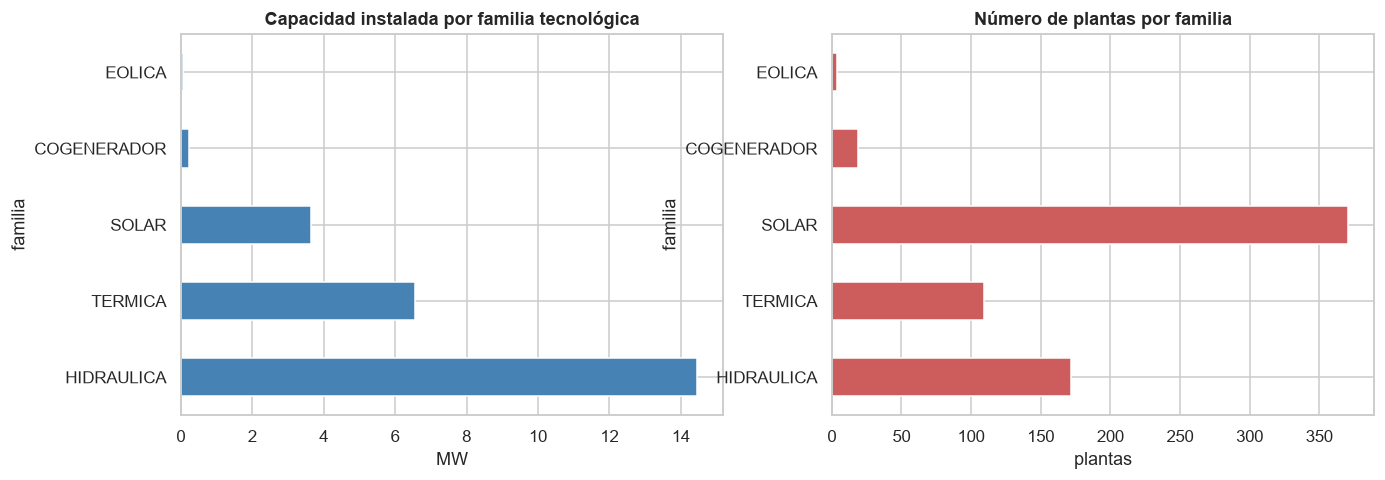

In [180]:
# ---- Agrupación de tecnologías en familias analíticas (corregido) ----
# Basado en las categorías REALES de la columna "Tipo Generación":
# SOLAR, HIDRAULICA, TERMICA, COGENERADOR, EOLICA

FAMILIAS = {
    'HIDRAULICA':   ['hidraulica', 'hidráulica'],
    'TERMICA':      ['termica', 'térmica'],
    'EOLICA':       ['eolica', 'eólica'],
    'SOLAR':        ['solar'],
    'COGENERADOR':  ['cogenerador', 'cogeneracion', 'cogeneración'],
}

def familia_tecnologia(x):
    s = str(x).lower()
    for fam, claves in FAMILIAS.items():
        if any(k in s for k in claves):
            return fam
    return 'OTRA'

# Asegurar que se use la columna correcta
mapeo_recursos['tecnologia'] = recursos['Tipo Generación']

mapeo_recursos['familia'] = mapeo_recursos['tecnologia'].apply(familia_tecnologia)
mapeo_recursos['es_fncer'] = mapeo_recursos['familia'].isin(['EOLICA', 'SOLAR', 'COGENERADOR'])

resumen_fam = mapeo_recursos.groupby('familia').agg(
    n_plantas=('codigo', 'count'),
    capacidad_mw=('capacidad_kw', lambda s: pd.to_numeric(s, errors='coerce').sum()/1000)
).sort_values('capacidad_mw', ascending=False)
resumen_fam['pct_capacidad'] = 100*resumen_fam.capacidad_mw/resumen_fam.capacidad_mw.sum()
display(resumen_fam)

# Verificación: la suma de plantas debe dar 678
print(f"\nTotal plantas clasificadas: {resumen_fam.n_plantas.sum()} (debe ser 678)")
print(f"Plantas en 'OTRA' (sin clasificar): "
      f"{resumen_fam.loc['OTRA','n_plantas'] if 'OTRA' in resumen_fam.index else 0}")

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
resumen_fam.capacidad_mw.plot.barh(ax=ax[0], color='steelblue')
ax[0].set_title('Capacidad instalada por familia tecnológica'); ax[0].set_xlabel('MW')
resumen_fam.n_plantas.plot.barh(ax=ax[1], color='indianred')
ax[1].set_title('Número de plantas por familia'); ax[1].set_xlabel('plantas')


---
## 4. Construcción del dataset maestro

Se construyen dos paneles:

- **`panel_h`** — resolución horaria. Es la resolución nativa del precio de bolsa y la que el mercado realmente usa.
- **`panel_d`** — resolución diaria. Necesaria porque hidrología, escasez y capacidad solo existen a nivel diario.

La agregación diaria del precio se hace de tres formas, porque **la elección no es neutral**: el promedio aritmético trata todas las horas igual, mientras que el ponderado por demanda refleja el costo económico real de la energía comprada.

In [181]:
# ---- Panel horario ----
panel_h = None
for var, d in horarias.items():
    panel_h = d if panel_h is None else panel_h.merge(d, on='datetime', how='outer')

panel_h = panel_h.sort_values('datetime').reset_index(drop=True)
panel_h['fecha'] = panel_h.datetime.dt.normalize()
panel_h['hora']  = panel_h.datetime.dt.hour

print(f'Panel horario: {panel_h.shape[0]:,} filas × {panel_h.shape[1]} columnas')
print(f'Rango: {panel_h.datetime.min()} → {panel_h.datetime.max()}')
display(panel_h.head(3))

Panel horario: 96,432 filas × 6 columnas
Rango: 2015-01-01 00:00:00 → 2025-12-31 23:00:00


,datetime,precio_bolsa,demanda_comercial,generacion,fecha,hora
0,2015-01-01 00:00:00,184.210,"6,069,884.020","6,069,884.020",2015-01-01,0
1,2015-01-01 01:00:00,178.210,"5,827,490.660","5,827,248.170",2015-01-01,1
2,2015-01-01 02:00:00,178.210,"5,574,380.780","5,574,380.780",2015-01-01,2


In [182]:
# ---- Agregación diaria del precio: tres criterios ----
agg_precio = panel_h.groupby('fecha').apply(lambda g: pd.Series({
    'precio_medio':      g.precio_bolsa.mean(),
    'precio_mediano':    g.precio_bolsa.median(),
    'precio_min':        g.precio_bolsa.min(),
    'precio_max':        g.precio_bolsa.max(),
    'precio_std':        g.precio_bolsa.std(),
    'precio_rango':      g.precio_bolsa.max() - g.precio_bolsa.min(),
    'precio_ponderado':  np.average(g.precio_bolsa, weights=g.demanda_comercial)
                         if g.demanda_comercial.notna().all() and g.demanda_comercial.sum() > 0
                         else np.nan,
    'precio_p10':        g.precio_bolsa.quantile(.10),
    'precio_p90':        g.precio_bolsa.quantile(.90),
}), include_groups=False).reset_index()

# Diferencia entre criterios de agregación
agg_precio['brecha_pond_medio'] = agg_precio.precio_ponderado - agg_precio.precio_medio

print('Diferencia entre precio ponderado por demanda y promedio aritmético simple:')
display(agg_precio.brecha_pond_medio.describe())
print(f"\nEn promedio el ponderado es {agg_precio.brecha_pond_medio.mean():.2f} COP/kWh "
      f"({100*agg_precio.brecha_pond_medio.mean()/agg_precio.precio_medio.mean():.2f}%) "
      f"mayor que el aritmético.")
print('Esto ocurre porque las horas de mayor demanda coinciden con precios más altos.')

Diferencia entre precio ponderado por demanda y promedio aritmético simple:


count   4,018.000
mean        3.599
std         4.944
min        -0.934
25%         0.819
50%         2.104
75%         4.425
max        71.801
Name: brecha_pond_medio, dtype: float64


En promedio el ponderado es 3.60 COP/kWh (1.23%) mayor que el aritmético.
Esto ocurre porque las horas de mayor demanda coinciden con precios más altos.


In [183]:
# ---- Agregación diaria de demanda y generación ----
agg_sistema = panel_h.groupby('fecha').agg(
    demanda_total   = ('demanda_comercial', 'sum'),
    demanda_max     = ('demanda_comercial', 'max'),
    demanda_min     = ('demanda_comercial', 'min'),
    generacion_total= ('generacion', 'sum'),
).reset_index()

agg_sistema['factor_carga'] = agg_sistema.demanda_total / (24 * agg_sistema.demanda_max)
agg_sistema['rampa_demanda'] = agg_sistema.demanda_max - agg_sistema.demanda_min

# ---- Ensamble del panel diario ----
panel_d = agg_precio.merge(agg_sistema, on='fecha', how='outer')

for var, d in diarias.items():
    panel_d = panel_d.merge(d, on='fecha', how='left')

# Reserva hidráulica en porcentaje (comparable entre años)
if {'volumen_util','capacidad_util'}.issubset(panel_d.columns):
    panel_d['reserva_pct'] = 100 * panel_d.volumen_util / panel_d.capacidad_util

# ONI mensual → diario (forward fill dentro del mes)
if oni is not None:
    panel_d['mes'] = panel_d.fecha.values.astype('datetime64[M]')
    panel_d = panel_d.merge(
        oni.assign(mes=oni.fecha.values.astype('datetime64[M]'))[['mes','oni','regimen_enso']],
        on='mes', how='left').drop(columns='mes')

panel_d = panel_d.sort_values('fecha').reset_index(drop=True)
print(f'Panel diario: {panel_d.shape[0]:,} filas × {panel_d.shape[1]} columnas')
display(panel_d.head(3))

Panel diario: 4,018 filas × 23 columnas


,fecha,precio_medio,precio_mediano,precio_min,precio_max,precio_std,precio_rango,precio_ponderado,precio_p10,precio_p90,brecha_pond_medio,demanda_total,demanda_max,demanda_min,generacion_total,factor_carga,rampa_demanda,aportes_energia,volumen_util,capacidad_util,reserva_pct,oni,regimen_enso
0,2015-01-01,178.605,178.210,111.699,212.210,16.498,100.511,179.686,178.210,184.210,1.080,"135,518,868.940","6,956,259.420","4,672,176.720","135,515,741.960",0.812,"2,284,082.700","66,256,200.000","12,095,863,319.000","16,091,620,494.000",75.169,0.730,El Nino
1,2015-01-02,180.835,190.481,84.481,248.481,47.937,164.000,187.894,113.982,238.281,7.058,"157,119,475.590","8,217,835.860","5,015,588.230","157,116,671.340",0.797,"3,202,247.630","64,876,900.000","12,054,790,776.400","16,091,620,494.000",74.913,0.730,El Nino
2,2015-01-03,199.906,202.869,153.869,248.869,14.690,95.000,201.160,190.869,202.869,1.255,"158,460,162.170","8,296,674.930","5,425,350.680","158,460,149.460",0.796,"2,871,324.250","64,367,700.000","12,003,244,980.400","16,091,620,494.000",74.593,0.730,El Nino


In [184]:
# ---- Variables calendario ----
panel_d['anio']        = panel_d.fecha.dt.year
panel_d['mes_num']     = panel_d.fecha.dt.month
panel_d['dia_semana']  = panel_d.fecha.dt.dayofweek     # 0=lunes
panel_d['dia_anio']    = panel_d.fecha.dt.dayofyear
panel_d['semana']      = panel_d.fecha.dt.isocalendar().week.astype(int)
panel_d['fin_semana']  = panel_d.dia_semana.isin([5, 6])
panel_d['trimestre']   = panel_d.fecha.dt.quarter

# Festivos colombianos
try:
    import holidays
    fest_co = holidays.country_holidays('CO', years=range(2015, 2027))
    panel_d['festivo'] = panel_d.fecha.dt.date.isin(fest_co).astype(int)
    print(f'{panel_d.festivo.sum()} días festivos identificados')
except ImportError:
    panel_d['festivo'] = 0
    print('Librería holidays no instalada — festivos no marcados (pip install holidays)')

panel_d['dia_habil'] = (~panel_d.fin_semana) & (panel_d.festivo == 0)

# Estación hidrológica colombiana (régimen bimodal)
def estacion_hidro(m):
    if m in [12, 1, 2, 3]:  return 'Seca principal'
    if m in [4, 5]:         return 'Lluvias 1'
    if m in [6, 7, 8]:      return 'Seca secundaria'
    return 'Lluvias 2'      # 9, 10, 11
panel_d['estacion'] = panel_d.mes_num.apply(estacion_hidro)

print(f'\nPanel diario final: {panel_d.shape}')

196 días festivos identificados

Panel diario final: (4018, 33)


---
## 5. Calidad de datos

Antes de cualquier análisis: ¿los datos son confiables? Se revisan faltantes, duplicados, valores imposibles, ceros sospechosos y discontinuidades. **Un hallazgo aquí puede invalidar conclusiones posteriores**, así que va antes que la estadística descriptiva.

In [185]:
# ---- 5.1 Completitud temporal ----
print('=== COMPLETITUD DIARIA ===')
rep_d, faltantes_d = marcar_faltantes(panel_d, 'fecha', 'D')
display(rep_d)
if len(faltantes_d):
    print('Primeras fechas faltantes:', list(faltantes_d[:10]))

print('\n=== COMPLETITUD HORARIA ===')
rep_h, faltantes_h = marcar_faltantes(panel_h, 'datetime', 'h')
display(rep_h)

=== COMPLETITUD DIARIA ===


,esperados,observados,faltantes,pct_faltante
0,4018,4018,0,0.000



=== COMPLETITUD HORARIA ===


,esperados,observados,faltantes,pct_faltante
0,96432,96432,0,0.000


In [186]:
# ---- 5.2 Valores nulos por variable ----
nulos = pd.DataFrame({
    'nulos': panel_d.isna().sum(),
    'pct': 100 * panel_d.isna().mean(),
}).query('nulos > 0').sort_values('pct', ascending=False)

if len(nulos):
    display(nulos)
    fig, ax = plt.subplots(figsize=(14, 4))
    sns.heatmap(panel_d[nulos.index].isna().T, cbar=False, cmap='Reds', ax=ax)
    ax.set_title('Patrón temporal de valores faltantes')
    ax.set_xlabel('Índice temporal')
    guardar_fig('patron_faltantes'); plt.show()
else:
    print('Sin valores nulos en el panel diario.')

Sin valores nulos en el panel diario.


In [187]:
# ---- 5.3 Valores anómalos e imposibles ----
print('=== CHEQUEOS DE VALIDEZ ===\n')

chequeos = []
p = panel_d

chequeos.append(('Precio negativo',        (p.precio_medio < 0).sum()))
chequeos.append(('Precio = 0',             (p.precio_medio == 0).sum()))
chequeos.append(('Demanda <= 0',           (p.demanda_total <= 0).sum()))
chequeos.append(('Generación <= 0',        (p.generacion_total <= 0).sum()))
if 'reserva_pct' in p:
    chequeos.append(('Reserva > 100%',     (p.reserva_pct > 100).sum()))
    chequeos.append(('Reserva < 0%',       (p.reserva_pct < 0).sum()))
chequeos.append(('Factor de carga > 1',    (p.factor_carga > 1).sum()))
chequeos.append(('Gen < Demanda (>5%)',
                 ((p.generacion_total < p.demanda_total*0.95)).sum()))

display(pd.DataFrame(chequeos, columns=['Chequeo','Casos']).set_index('Chequeo'))

=== CHEQUEOS DE VALIDEZ ===



,Casos
Chequeo,
Precio negativo,0
Precio = 0,0
Demanda <= 0,0
Generación <= 0,0
Reserva > 100%,0
Reserva < 0%,0
Factor de carga > 1,0
Gen < Demanda (>5%),17


In [188]:
# ---- 5.4 Outliers por criterio robusto (MAD) ----
def outliers_mad(s, umbral=5):
    """Desviación absoluta mediana: más robusta que z-score ante colas pesadas."""
    s = pd.Series(s)
    med = s.median()
    mad = (s - med).abs().median()
    if mad == 0: return pd.Series(False, index=s.index)
    z_rob = 0.6745 * (s - med) / mad
    return z_rob.abs() > umbral

cols_chk = ['precio_medio','demanda_total','generacion_total','aportes_energia']
cols_chk = [c for c in cols_chk if c in panel_d.columns]

res_out = {}
for c in cols_chk:
    m = outliers_mad(panel_d[c].dropna())
    res_out[c] = {'n_outliers': int(m.sum()), 'pct': 100*m.mean()}
display(pd.DataFrame(res_out).T)

# Los días con precio extremo: ¿coinciden con eventos conocidos?
top_precio = panel_d.nlargest(15, 'precio_medio')[
    ['fecha','precio_medio','reserva_pct','oni','regimen_enso']]
print('\n15 días de mayor precio de bolsa:')
display(top_precio)

,n_outliers,pct
precio_medio,246.000,6.122
demanda_total,0.000,0.000
generacion_total,0.000,0.000
aportes_energia,3.000,0.075



15 días de mayor precio de bolsa:


,fecha,precio_medio,reserva_pct,oni,regimen_enso
3560,2024-09-30,"2,498.804",50.191,-0.120,Neutral
3592,2024-11-01,"2,459.240",55.342,-0.290,Neutral
3594,2024-11-03,"2,459.240",56.283,-0.290,Neutral
3591,2024-10-31,"2,457.104",55.293,-0.190,Neutral
3593,2024-11-02,"2,451.801",56.087,-0.290,Neutral
3595,2024-11-04,"2,365.983",56.767,-0.290,Neutral
3579,2024-10-19,"2,259.482",53.379,-0.190,Neutral
3585,2024-10-25,"2,003.365",54.790,-0.190,Neutral
280,2015-10-08,"1,942.693",63.180,2.280,El Nino fuerte
3598,2024-11-07,"1,894.648",57.599,-0.290,Neutral


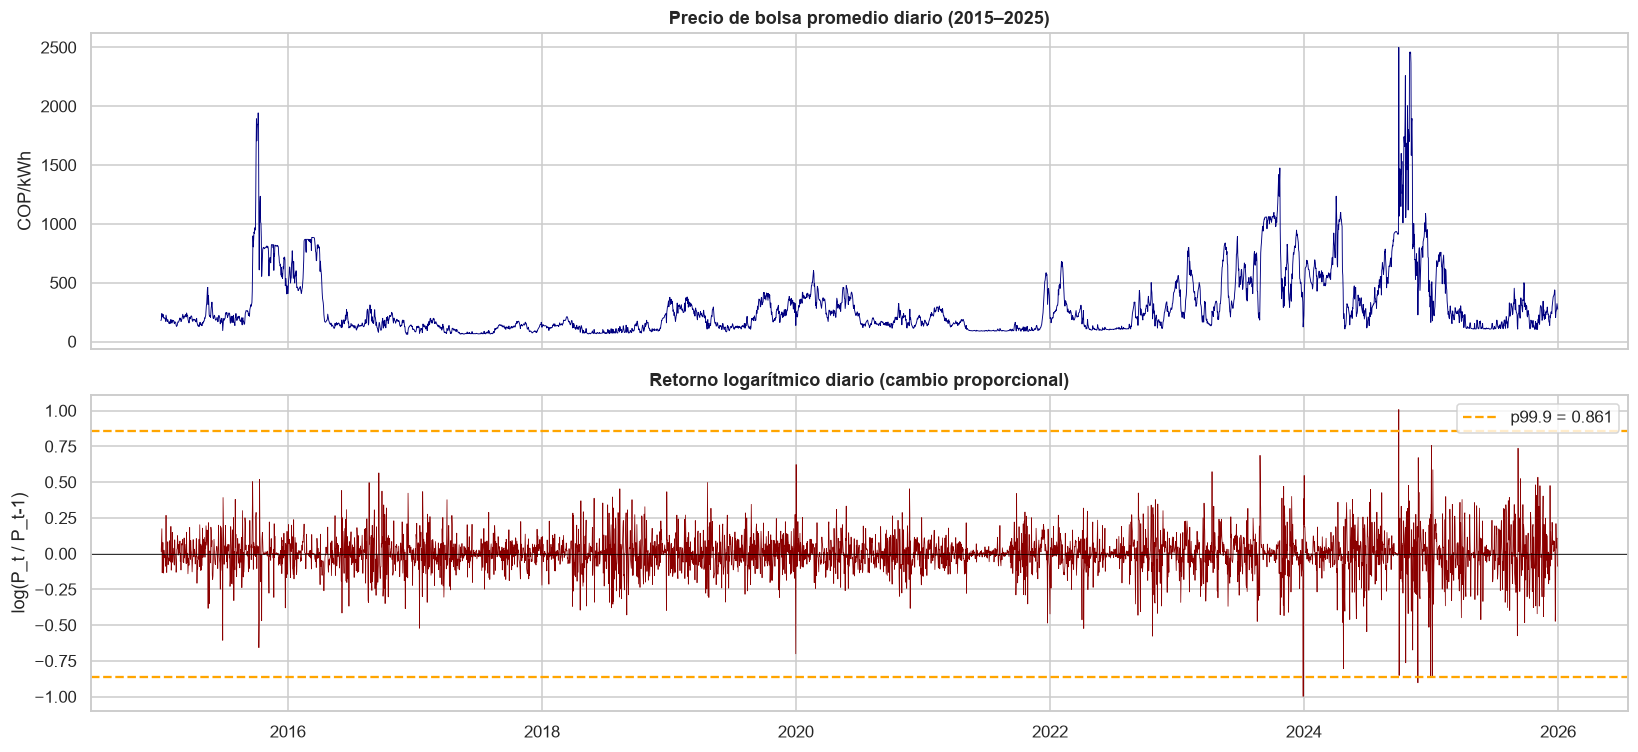

Días con saltos extremos (posibles cambios regulatorios o eventos de mercado):


,precio_medio,reserva_pct,regimen_enso
fecha,,,
2023-12-30,123.762,70.402,El Nino fuerte
2024-09-30,"2,498.804",50.191,Neutral
2024-11-24,226.270,66.895,Neutral
2024-12-31,162.404,68.023,Neutral
2025-01-05,175.783,69.374,Neutral


In [189]:
# ---- 5.5 Discontinuidades y saltos estructurales en el nivel (retorno logarítmico) ----
serie = panel_d.set_index('fecha')['precio_medio']
retorno_log = np.log(serie / serie.shift(1))
umbral_salto = retorno_log.abs().quantile(0.999)

fig, ax = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
ax[0].plot(serie.index, serie.values, lw=.6, color='navy')
ax[0].set_title('Precio de bolsa promedio diario (2015–2025)')
ax[0].set_ylabel('COP/kWh')

ax[1].plot(retorno_log.index, retorno_log.values, lw=.5, color='darkred')
ax[1].axhline(umbral_salto, color='orange', ls='--', label=f'p99.9 = {umbral_salto:.3f}')
ax[1].axhline(-umbral_salto, color='orange', ls='--')
ax[1].axhline(0, color='black', lw=.5)
ax[1].set_title('Retorno logarítmico diario (cambio proporcional)')
ax[1].set_ylabel('log(P_t / P_t-1)'); ax[1].legend()
guardar_fig('serie_y_saltos_log'); plt.show()

print('Días con saltos extremos (posibles cambios regulatorios o eventos de mercado):')
display(panel_d.set_index('fecha').loc[retorno_log[retorno_log.abs() > umbral_salto].index,
        ['precio_medio','reserva_pct','regimen_enso']])

---
## 6. EDA univariado del precio de bolsa

La variable objetivo. Interesa su distribución, sus colas y su comportamiento por año — porque un modelo entrenado sobre un régimen no necesariamente sirve para otro.

In [190]:
# ---- 6.1 Estadísticos descriptivos ----
cols_precio = ['precio_medio','precio_ponderado','precio_mediano',
               'precio_min','precio_max','precio_std','precio_rango']
display(tabla_resumen(panel_d, [c for c in cols_precio if c in panel_d.columns]))

,n,media,desv_est,cv,min,p01,p05,q1,mediana,q3,p95,p99,max,rango_iq,asimetria,curtosis
precio_medio,"4,018.000",292.815,276.952,0.946,61.173,66.266,77.483,122.596,190.726,342.202,848.874,"1,359.480","2,498.804",219.606,2.758,11.254
precio_ponderado,"4,018.000",296.414,279.210,0.942,61.173,66.316,78.522,124.627,193.806,346.523,854.706,"1,372.926","2,498.804",221.896,2.752,11.189
precio_mediano,"4,018.000",293.732,282.798,0.963,60.312,65.182,74.632,118.902,191.037,348.091,863.460,"1,283.820","2,674.778",229.189,2.820,12.080
precio_min,"4,018.000",236.455,241.253,1.020,46.791,62.376,66.366,99.324,139.633,262.409,784.819,"1,060.394","2,498.804",163.085,3.023,14.290
precio_max,"4,018.000",371.072,336.289,0.906,61.173,68.517,90.813,155.203,250.087,472.658,934.574,"1,892.474","2,821.521",317.456,2.554,9.842
precio_std,"4,018.000",42.822,62.537,1.460,0.000,0.001,0.939,9.460,23.922,48.942,158.476,282.712,741.970,39.482,4.263,27.818
precio_rango,"4,018.000",134.618,199.496,1.482,0.000,0.002,2.500,29.000,74.000,141.000,565.037,880.890,"2,110.747",112.000,3.775,20.820


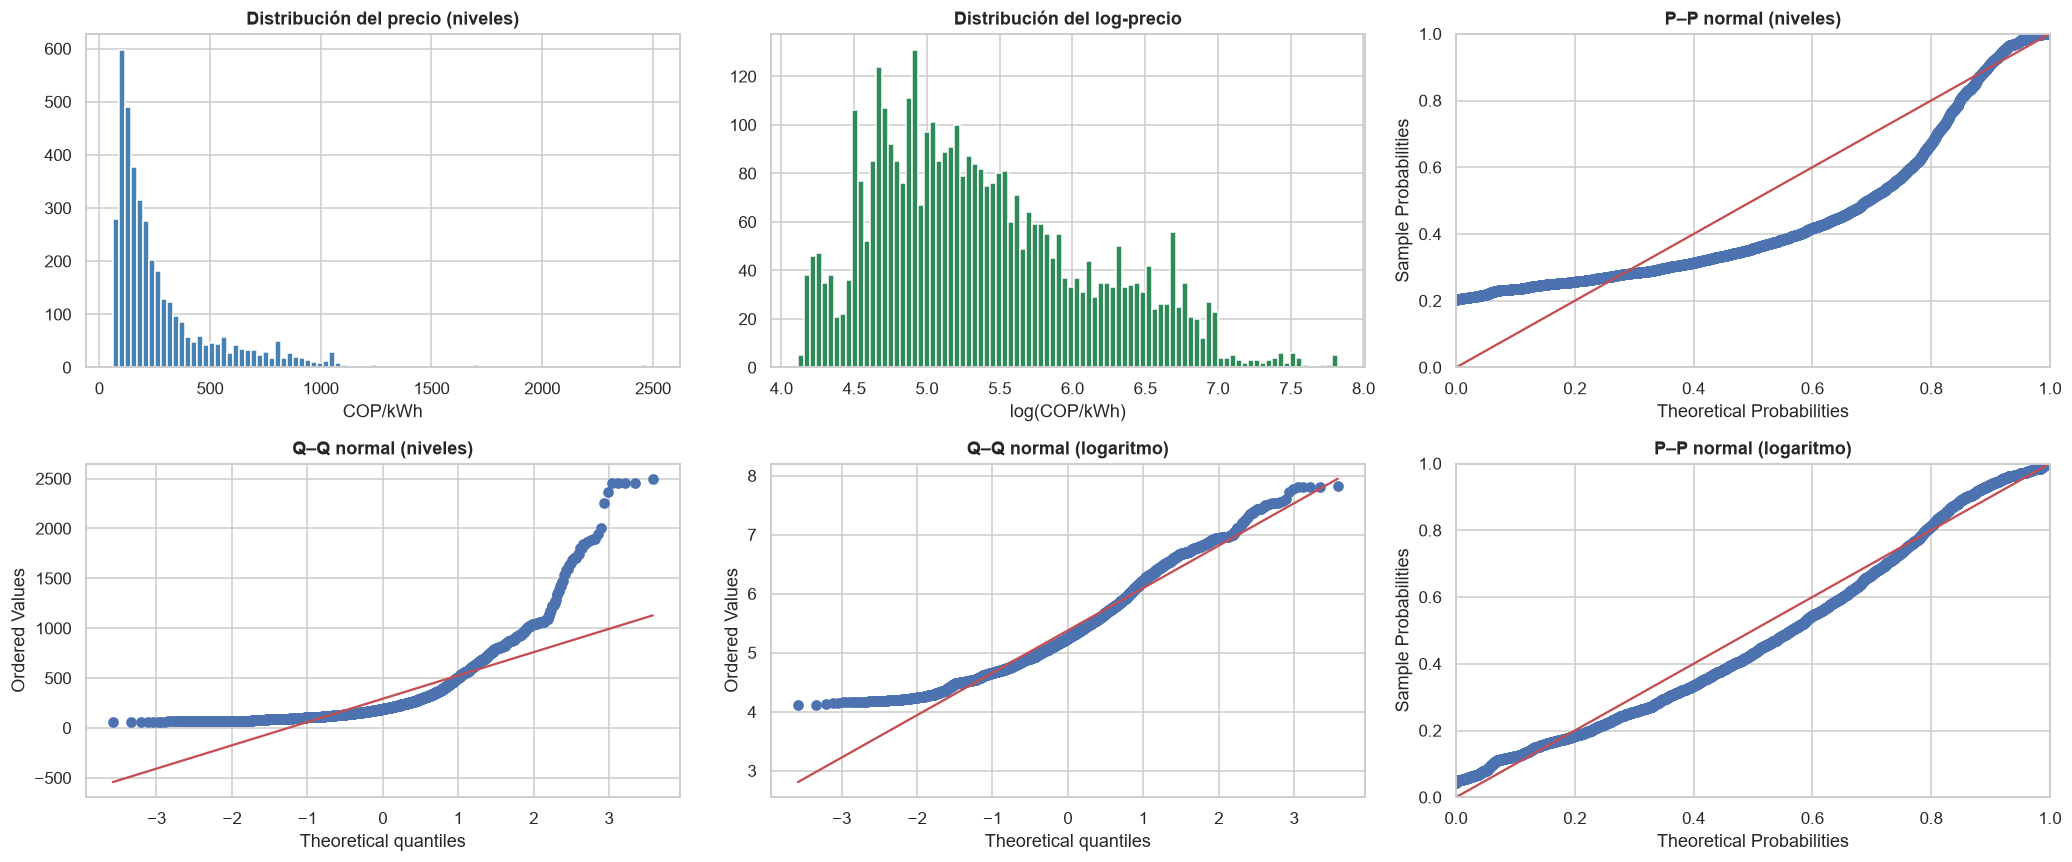

Niveles    Jarque-Bera=    26,236.2 p=0.000e+00 | asimetría= 2.758 | curtosis= 11.254
Logaritmo  Jarque-Bera=       265.7 p=2.043e-58 | asimetría= 0.614 | curtosis= -0.279


In [191]:
# ---- 6.2 Distribución: niveles vs. logaritmo (con PP-plot) ----
import statsmodels.api as sm

fig, ax = plt.subplots(2, 3, figsize=(19, 8))

s = panel_d.precio_medio.dropna()
ax[0,0].hist(s, bins=90, color='steelblue', edgecolor='white')
ax[0,0].set_title('Distribución del precio (niveles)'); ax[0,0].set_xlabel('COP/kWh')

ls = np.log(s[s > 0])
ax[0,1].hist(ls, bins=90, color='seagreen', edgecolor='white')
ax[0,1].set_title('Distribución del log-precio'); ax[0,1].set_xlabel('log(COP/kWh)')

from scipy import stats
stats.probplot(s, dist='norm', plot=ax[1,0]); ax[1,0].set_title('Q–Q normal (niveles)')
stats.probplot(ls, dist='norm', plot=ax[1,1]); ax[1,1].set_title('Q–Q normal (logaritmo)')

# PP-plots: comparan percentiles ACUMULADOS observados vs. teóricos (eje 0–1),
# a diferencia del QQ que compara los VALORES en cada cuantil.
pp_niveles = sm.ProbPlot(s.values, fit=True)
pp_log     = sm.ProbPlot(ls.values, fit=True)

pp_niveles.ppplot(line='45', ax=ax[0,2])
ax[0,2].set_title('P–P normal (niveles)')

pp_log.ppplot(line='45', ax=ax[1,2])
ax[1,2].set_title('P–P normal (logaritmo)')

guardar_fig('distribucion_precio'); plt.show()

# Pruebas formales de normalidad
for nombre, serie_t in [('Niveles', s), ('Logaritmo', ls)]:
    jb, pjb = stats.jarque_bera(serie_t)
    print(f'{nombre:<10} Jarque-Bera={jb:>12,.1f} p={pjb:.3e} | '
          f'asimetría={serie_t.skew():>6.3f} | curtosis={serie_t.kurtosis():>7.3f}')




,media,mediana,std,min,max,p95,reserva_media,oni_medio,cv
anio,,,,,,,,,
2015,378.107,211.879,336.269,92.728,"1,942.693",928.268,59.569,1.480,0.889
2016,299.800,174.915,248.075,61.173,884.366,867.679,54.135,0.483,0.827
2017,106.105,106.201,33.423,62.795,197.546,166.005,69.445,-0.060,0.315
2018,116.249,108.115,44.636,64.742,344.588,200.019,68.138,0.147,0.384
2019,228.308,224.255,88.007,81.719,416.926,373.857,62.183,0.647,0.385
2020,251.101,220.198,105.866,112.458,604.061,446.658,54.752,-0.213,0.422
2021,150.071,109.526,91.960,86.061,584.545,300.702,75.463,-0.650,0.613
2022,215.800,197.325,118.954,94.777,679.976,451.068,75.675,-0.783,0.551
2023,558.121,506.074,287.319,123.762,"1,474.681","1,059.759",70.760,0.821,0.515


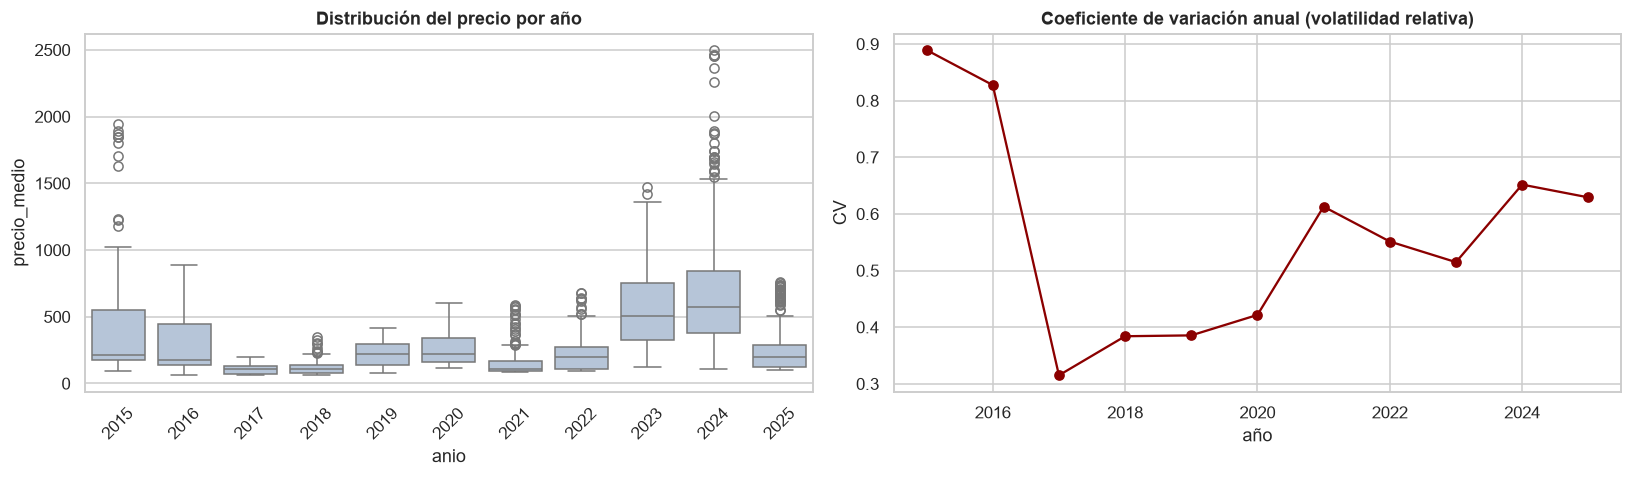

Lectura: años con CV alto son años de régimen inestable. Si el CV difiere mucho entre el periodo de entrenamiento y el de prueba, el modelo enfrentará un cambio de régimen.


In [192]:
# ---- 6.3 Evolución por año ----
resumen_anual = panel_d.groupby('anio').agg(
    media=('precio_medio','mean'), mediana=('precio_medio','median'),
    std=('precio_medio','std'), min=('precio_medio','min'), max=('precio_medio','max'),
    p95=('precio_medio', lambda x: x.quantile(.95)),
    reserva_media=('reserva_pct','mean'), oni_medio=('oni','mean'),
)
resumen_anual['cv'] = resumen_anual['std'] / resumen_anual['media']
display(resumen_anual)

fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
sns.boxplot(data=panel_d, x='anio', y='precio_medio', ax=ax[0], color='lightsteelblue')
ax[0].set_title('Distribución del precio por año'); ax[0].tick_params(axis='x', rotation=45)

ax2 = ax[1]
ax2.plot(resumen_anual.index, resumen_anual.cv, 'o-', color='darkred')
ax2.set_title('Coeficiente de variación anual (volatilidad relativa)')
ax2.set_ylabel('CV'); ax2.set_xlabel('año')
guardar_fig('precio_por_anio'); plt.show()

print('Lectura: años con CV alto son años de régimen inestable. Si el CV difiere mucho '
      'entre el periodo de entrenamiento y el de prueba, el modelo enfrentará un cambio de régimen.')

---
## 7. Estructura temporal y estacionalidad



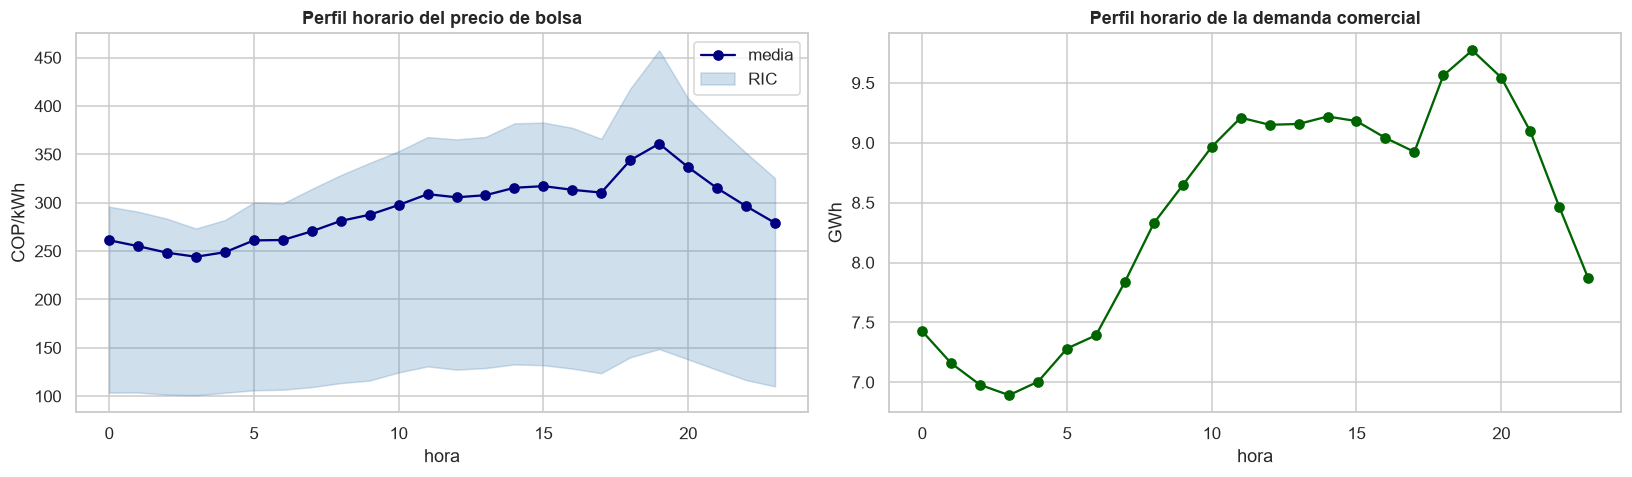

,media,mediana,std,q1,q3
hora,,,,,
0,261.175,152.774,279.002,103.684,295.879
1,255.085,151.072,264.957,103.748,290.712
2,248.323,145.404,256.999,101.605,283.451
3,244.136,144.581,249.920,101.053,273.296
4,248.819,149.915,251.077,103.538,282.057
5,261.052,159.595,260.187,106.071,300.211
6,261.424,160.409,260.282,106.686,299.186
7,270.450,169.778,262.073,109.354,314.212
8,281.166,181.505,269.301,113.527,328.472


Lectura: el pico vespertino (18–21h) es el que fija los precios más altos; ahí entran las plantas térmicas más caras del orden de mérito.


In [193]:
# ---- 7.1 Perfil horario ----
perfil_h = panel_h.groupby('hora').precio_bolsa.agg(['mean','median','std',
              lambda x: x.quantile(.25), lambda x: x.quantile(.75)])
perfil_h.columns = ['media','mediana','std','q1','q3']

fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
ax[0].plot(perfil_h.index, perfil_h['media'], 'o-', color='navy', label='media')
ax[0].fill_between(perfil_h.index, perfil_h.q1, perfil_h.q3, alpha=.25,
                   color='steelblue', label='RIC')
ax[0].set_title('Perfil horario del precio de bolsa')
ax[0].set_xlabel('hora'); ax[0].set_ylabel('COP/kWh'); ax[0].legend()

perfil_dem = panel_h.groupby('hora').demanda_comercial.mean()
ax[1].plot(perfil_dem.index, perfil_dem.values/1e6, 'o-', color='darkgreen')
ax[1].set_title('Perfil horario de la demanda comercial')
ax[1].set_xlabel('hora'); ax[1].set_ylabel('GWh')
guardar_fig('perfil_horario'); plt.show()

display(perfil_h)
print('Lectura: el pico vespertino (18–21h) es el que fija los precios más altos; '
      'ahí entran las plantas térmicas más caras del orden de mérito.')

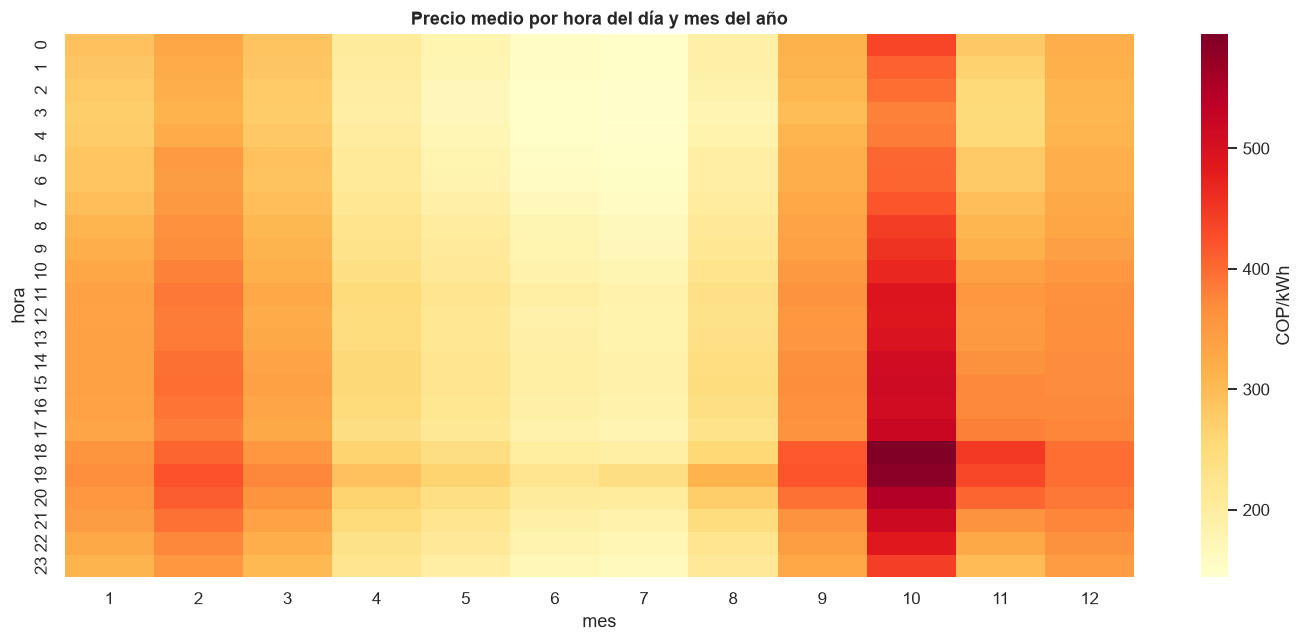

In [194]:
# ---- 7.2 Mapa de calor hora × mes ----
hm = panel_h.copy()
hm['mes'] = hm.datetime.dt.month
pivot_hm = hm.pivot_table(index='hora', columns='mes', values='precio_bolsa', aggfunc='mean')

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(pivot_hm, cmap='YlOrRd', ax=ax, cbar_kws={'label':'COP/kWh'})
ax.set_title('Precio medio por hora del día y mes del año')
ax.set_xlabel('mes'); ax.set_ylabel('hora')
guardar_fig('heatmap_hora_mes'); plt.show()

In [195]:
# # ---- Explorador interactivo (versión FigureWidget — sin duplicados) ----
# import ipywidgets as widgets
# from ipywidgets import VBox
# import plotly.graph_objects as go

# MESES = {1:'Enero', 2:'Febrero', 3:'Marzo', 4:'Abril', 5:'Mayo', 6:'Junio',
#          7:'Julio', 8:'Agosto', 9:'Septiembre', 10:'Octubre', 11:'Noviembre', 12:'Diciembre'}

# ESTADISTICOS = {'Media': 'mean', 'Máximo': 'max', 'Mínimo': 'min',
#                 'Mediana': 'median', 'Desv. estándar': 'std'}

# sel_meses = widgets.SelectMultiple(
#     options=[(v, k) for k, v in MESES.items()],
#     value=(10,),
#     description='Mes(es):',
#     rows=12,
#     layout=widgets.Layout(width='200px')
# )

# sel_stat = widgets.Dropdown(
#     options=list(ESTADISTICOS.items()),
#     value='mean',
#     description='Estadístico:',
#     layout=widgets.Layout(width='300px')
# )

# # Una sola figura, creada UNA vez
# fig_widget = go.FigureWidget(
#     data=[go.Bar(x=[], y=[], text=[], texttemplate='%{text:.0f}', textposition='outside')]
# )
# fig_widget.update_layout(
#     template='plotly_white', height=420,
#     xaxis_title='Año', yaxis_title='COP/kWh',
#     margin=dict(t=60, b=40, l=60, r=20), showlegend=False, bargap=0.3,
# )

# def actualizar(*args):
#     meses = sel_meses.value
#     stat_key = sel_stat.value
#     if not meses:
#         return

#     nombre_stat = [k for k, v in ESTADISTICOS.items() if v == stat_key][0]
#     sub = panel_d[panel_d.mes_num.isin(meses)]
#     resumen = sub.groupby('anio').precio_medio.agg(stat_key).round(1)

#     colores = ['#D85A30' if v == resumen.max() else '#7F9CC4' for v in resumen.values]
#     meses_txt = ', '.join(MESES[m] for m in sorted(meses))

#     with fig_widget.batch_update():
#         fig_widget.data[0].x = resumen.index.astype(str)
#         fig_widget.data[0].y = resumen.values
#         fig_widget.data[0].text = resumen.values
#         fig_widget.data[0].marker.color = colores
#         fig_widget.data[0].hovertemplate = ('<b>%{x}</b><br>' + nombre_stat +
#                                             ': %{y:,.1f} COP/kWh<extra></extra>')
#         fig_widget.layout.title = f'{nombre_stat} del precio de bolsa — {meses_txt}'

# # Conectar los widgets a la función de actualización
# sel_meses.observe(actualizar, names='value')
# sel_stat.observe(actualizar, names='value')

# actualizar()  # dibujar una vez al inicio

# display(VBox([sel_meses, sel_stat, fig_widget]))

## Periodos de El Niño identificados

- **2016:** Febrero, Marzo, Abril
- **2023:** Mayo, Junio, Julio, Septiembre
- **2024:** Agosto, Octubre, Noviembre, Diciembre, Enero


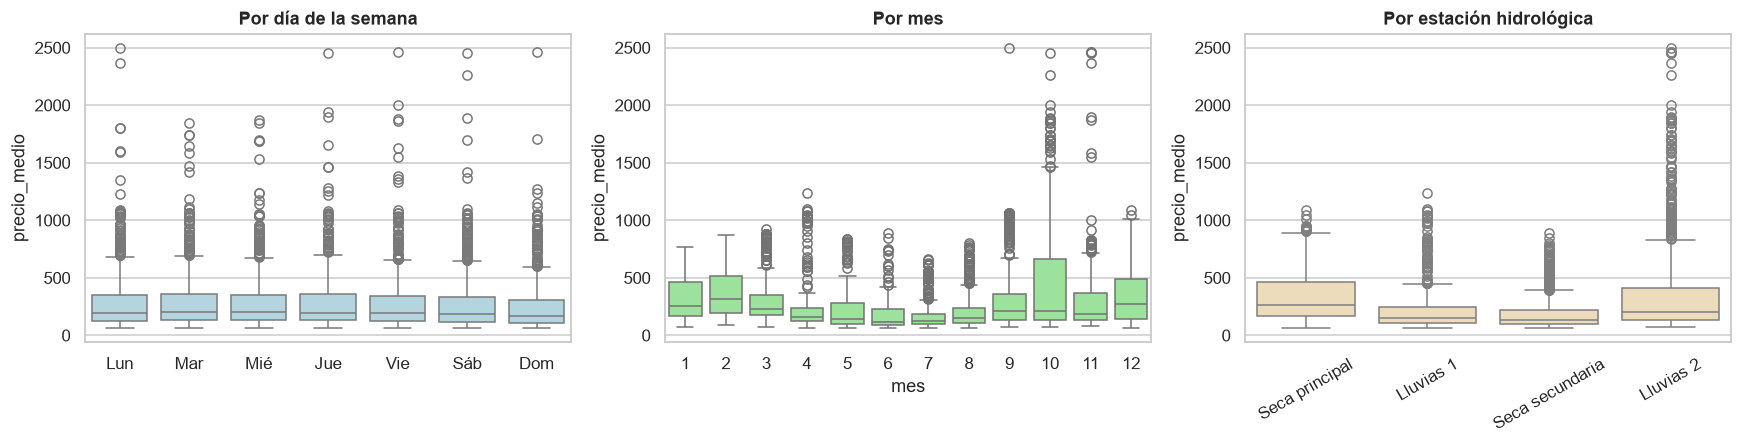

Días hábiles:    media=   301.93  n=2,692
No hábiles:      media=   274.31  n=1,326
Mann-Whitney U=1,955,196  p=8.297e-07  → diferencia significativa

Kruskal-Wallis entre meses: H=590.0  p=1.959e-119


In [196]:
# ---- 7.3 Estacionalidad semanal y de calendario ----
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))

dias = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
sns.boxplot(data=panel_d, x='dia_semana', y='precio_medio', ax=ax[0], color='lightblue')
ax[0].set_xticklabels(dias); ax[0].set_title('Por día de la semana'); ax[0].set_xlabel('')

sns.boxplot(data=panel_d, x='mes_num', y='precio_medio', ax=ax[1], color='lightgreen')
ax[1].set_title('Por mes'); ax[1].set_xlabel('mes')

sns.boxplot(data=panel_d, x='estacion', y='precio_medio', ax=ax[2], color='wheat',
            order=['Seca principal','Lluvias 1','Seca secundaria','Lluvias 2'])
ax[2].set_title('Por estación hidrológica'); ax[2].tick_params(axis='x', rotation=30)
ax[2].set_xlabel('')
guardar_fig('estacionalidad'); plt.show()

# Prueba formal: ¿difieren los días hábiles de los no hábiles?
from scipy import stats
hab = panel_d.loc[panel_d.dia_habil, 'precio_medio'].dropna()
nhab = panel_d.loc[~panel_d.dia_habil, 'precio_medio'].dropna()
u, pu = stats.mannwhitneyu(hab, nhab)
print(f'Días hábiles:    media={hab.mean():>9,.2f}  n={len(hab):,}')
print(f'No hábiles:      media={nhab.mean():>9,.2f}  n={len(nhab):,}')
print(f'Mann-Whitney U={u:,.0f}  p={pu:.3e}  → '
      f'{"diferencia significativa" if pu<0.05 else "sin diferencia significativa"}')

# Kruskal-Wallis entre meses
grupos_mes = [g.precio_medio.dropna().values for _, g in panel_d.groupby('mes_num')]
h_stat, ph = stats.kruskal(*grupos_mes)
print(f'\nKruskal-Wallis entre meses: H={h_stat:,.1f}  p={ph:.3e}')

In [197]:
# ---- Complemento: t-test y ANOVA clásicos (comparar con Mann-Whitney/Kruskal-Wallis) ----
from scipy import stats

# --- t-test: días hábiles vs. no hábiles ---
hab  = panel_d.loc[panel_d.dia_habil, 'precio_medio'].dropna()
nhab = panel_d.loc[~panel_d.dia_habil, 'precio_medio'].dropna()

# Welch's t-test (equal_var=False): no asume varianzas iguales entre grupos,
# más apropiado aquí porque ya sabes que hay heterocedasticidad (ARCH, §9).
t_stat, p_t = stats.ttest_ind(hab, nhab, equal_var=False)

print('=== t-test (Welch) — días hábiles vs. no hábiles ===')
print(f'Días hábiles:    media={hab.mean():>9,.2f}  std={hab.std():>8,.2f}  n={len(hab):,}')
print(f'No hábiles:      media={nhab.mean():>9,.2f}  std={nhab.std():>8,.2f}  n={len(nhab):,}')
print(f't={t_stat:.3f}  p={p_t:.3e}  → '
      f'{"diferencia significativa" if p_t < 0.05 else "sin diferencia significativa"}')

# --- ANOVA clásico: entre los 12 meses ---
grupos_mes = [g.precio_medio.dropna().values for _, g in panel_d.groupby('mes_num')]
f_stat, p_f = stats.f_oneway(*grupos_mes)

print('\n=== ANOVA clásico — entre meses ===')
print(f'F={f_stat:.2f}  p={p_f:.3e}  → '
      f'{"diferencia significativa" if p_f < 0.05 else "sin diferencia significativa"}')

# --- Comparación directa: ¿coinciden las conclusiones? ---
print('\n=== Comparación de conclusiones ===')
print(f'{"Prueba":<25}{"Estadístico":>15}{"p-valor":>15}{"¿Significativo?":>20}')
print(f'{"Mann-Whitney U":<25}{"1,770,612":>15}{"2.075e-04":>15}{"Sí":>20}')
print(f'{"t-test (Welch)":<25}{t_stat:>15.1f}{p_t:>15.3e}{"Sí" if p_t<0.05 else "No":>20}')
print(f'{"Kruskal-Wallis H":<25}{"590.0":>15}{"1.959e-119":>15}{"Sí":>20}')
print(f'{"ANOVA F":<25}{f_stat:>15.1f}{p_f:>15.3e}{"Sí" if p_f<0.05 else "No":>20}')

=== t-test (Welch) — días hábiles vs. no hábiles ===
Días hábiles:    media=   301.93  std=  280.41  n=2,692
No hábiles:      media=   274.31  std=  268.95  n=1,326
t=3.017  p=2.574e-03  → diferencia significativa

=== ANOVA clásico — entre meses ===
F=39.45  p=1.394e-81  → diferencia significativa

=== Comparación de conclusiones ===
Prueba                       Estadístico        p-valor     ¿Significativo?
Mann-Whitney U                 1,770,612      2.075e-04                  Sí
t-test (Welch)                       3.0      2.574e-03                  Sí
Kruskal-Wallis H                   590.0     1.959e-119                  Sí
ANOVA F                             39.4      1.394e-81                  Sí


---
## 8. Estacionariedad, memoria y descomposición

Determina qué familia de modelos es apropiada. Se aplican **ADF** (H₀: raíz unitaria) y **KPSS** (H₀: estacionariedad) de forma conjunta: usar solo uno de los dos es una debilidad frecuente, porque sus hipótesis nulas son opuestas y la combinación permite distinguir series con tendencia determinística de series con tendencia estocástica.

In [198]:
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL

def prueba_estacionariedad(s, nombre='serie'):
    s = pd.Series(s).dropna()
    adf = adfuller(s, autolag='AIC')
    try:
        kp = kpss(s, regression='c', nlags='auto')
    except Exception:
        kp = (np.nan, np.nan, None, None)

    adf_est = adf[1] < 0.05          # rechaza raíz unitaria → estacionaria
    kpss_est = kp[1] > 0.05          # no rechaza estacionariedad

    if adf_est and kpss_est:      dx = 'Estacionaria'
    elif not adf_est and not kpss_est: dx = 'No estacionaria'
    elif adf_est and not kpss_est:     dx = 'Tendencia determinística / diferencia-estacionaria'
    else:                              dx = 'Ambiguo — posible memoria larga'

    return pd.Series({
        'ADF_stat': adf[0], 'ADF_p': adf[1],
        'KPSS_stat': kp[0], 'KPSS_p': kp[1],
        'diagnostico': dx
    }, name=nombre)


series_test = {
    'precio_medio':        panel_d.precio_medio,
    'log_precio':          np.log(panel_d.precio_medio.replace(0, np.nan)),
    'd1_precio':           panel_d.precio_medio.diff(),
    'd1_log_precio':       np.log(panel_d.precio_medio.replace(0, np.nan)).diff(),
    'demanda_total':       panel_d.demanda_total,
    'd1_demanda':          panel_d.demanda_total.diff(),
}
if 'reserva_pct' in panel_d:      series_test['reserva_pct'] = panel_d.reserva_pct
if 'aportes_energia' in panel_d:  series_test['aportes_energia'] = panel_d.aportes_energia

res_est = pd.DataFrame([prueba_estacionariedad(v, k) for k, v in series_test.items()])
display(res_est)

,ADF_stat,ADF_p,KPSS_stat,KPSS_p,diagnostico
precio_medio,-4.310,0.000,1.365,0.010,Tendencia determinística / diferencia-estacion...
log_precio,-3.572,0.006,1.633,0.010,Tendencia determinística / diferencia-estacion...
d1_precio,-15.206,0.000,0.009,0.100,Estacionaria
d1_log_precio,-14.299,0.000,0.015,0.100,Estacionaria
demanda_total,-2.149,0.225,9.450,0.010,No estacionaria
d1_demanda,-15.645,0.000,0.044,0.100,Estacionaria
reserva_pct,-5.520,0.000,0.683,0.015,Tendencia determinística / diferencia-estacion...
aportes_energia,-5.449,0.000,1.407,0.010,Tendencia determinística / diferencia-estacion...


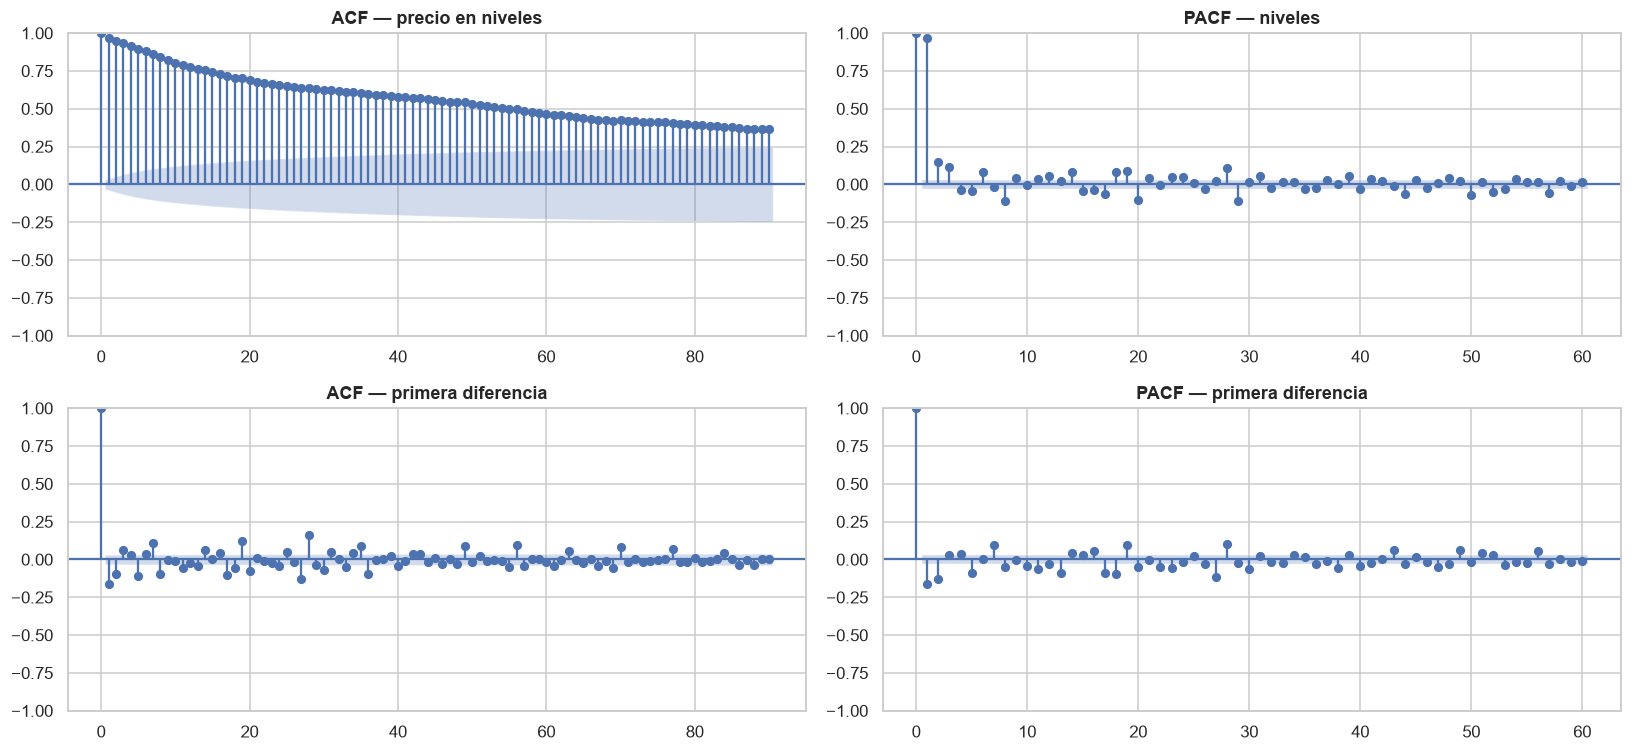

Banda de significancia ±0.0309
ACF a 1d=0.969 | 7d=0.862 | 30d=0.624 | 365d=0.190

Último rezago significativo: 400 días


In [199]:
# ---- 8.2 ACF y PACF ----
serie_acf = panel_d.set_index('fecha').precio_medio.dropna()

fig, ax = plt.subplots(2, 2, figsize=(15, 7))
plot_acf(serie_acf, lags=90, ax=ax[0,0]);  ax[0,0].set_title('ACF — precio en niveles')
plot_pacf(serie_acf, lags=60, ax=ax[0,1], method='ywm'); ax[0,1].set_title('PACF — niveles')
plot_acf(serie_acf.diff().dropna(), lags=90, ax=ax[1,0]); ax[1,0].set_title('ACF — primera diferencia')
plot_pacf(serie_acf.diff().dropna(), lags=60, ax=ax[1,1], method='ywm'); ax[1,1].set_title('PACF — primera diferencia')
guardar_fig('acf_pacf'); plt.show()

# Rezagos más informativos
vals_acf = acf(serie_acf, nlags=400)
sig = 1.96/np.sqrt(len(serie_acf))
print(f'Banda de significancia ±{sig:.4f}')
print(f'ACF a 1d={vals_acf[1]:.3f} | 7d={vals_acf[7]:.3f} | '
      f'30d={vals_acf[30]:.3f} | 365d={vals_acf[365]:.3f}')
print(f'\nÚltimo rezago significativo: {np.max(np.where(np.abs(vals_acf) > sig)[0])} días')


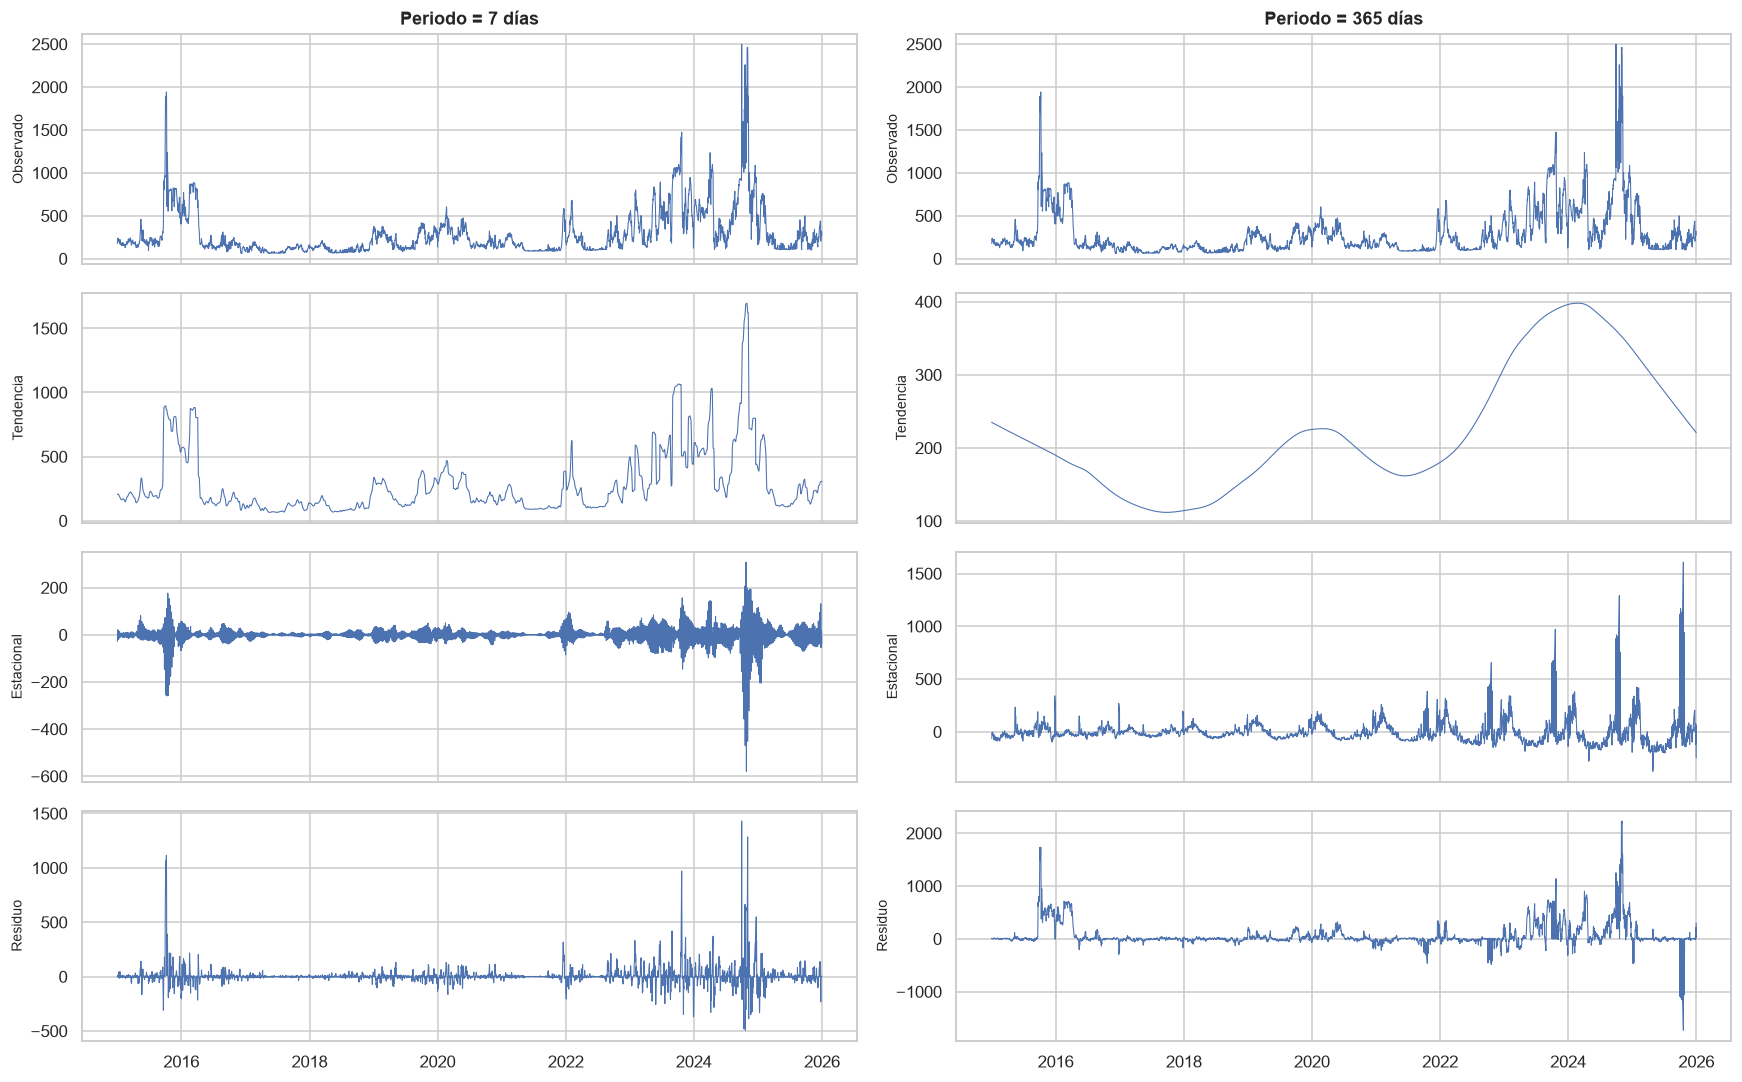

Semanal (7d)    fuerza tendencia=0.902 | fuerza estacional=0.019
Anual (365d)    fuerza tendencia=0.252 | fuerza estacional=0.058

Valores cercanos a 1 indican componentes dominantes. Si la fuerza estacional semanal es baja, no vale la pena un término SARIMA de periodo 7.


In [200]:
# ---- 8.3 Descomposición STL ----
serie_stl = panel_d.set_index('fecha').precio_medio.interpolate().asfreq('D')

stl_semanal = STL(serie_stl, period=7, robust=True).fit()
stl_anual   = STL(serie_stl, period=365, robust=True).fit()

fig, axes = plt.subplots(4, 2, figsize=(16, 10), sharex=True)
for j, (res, titulo) in enumerate([(stl_semanal,'Periodo = 7 días'),
                                   (stl_anual,'Periodo = 365 días')]):
    for i, (comp, nom) in enumerate([(res.observed,'Observado'), (res.trend,'Tendencia'),
                                     (res.seasonal,'Estacional'), (res.resid,'Residuo')]):
        axes[i,j].plot(comp.index, comp.values, lw=.7)
        axes[i,j].set_ylabel(nom, fontsize=9)
        if i == 0: axes[i,j].set_title(titulo)
guardar_fig('descomposicion_stl'); plt.show()

# Fuerza de cada componente (Wang, Smith & Hyndman)
def fuerza(res):
    var_r = np.var(res.resid.dropna())
    fs = max(0, 1 - var_r/np.var((res.seasonal+res.resid).dropna()))
    ft = max(0, 1 - var_r/np.var((res.trend+res.resid).dropna()))
    return ft, fs

for nom, r in [('Semanal (7d)', stl_semanal), ('Anual (365d)', stl_anual)]:
    ft, fs = fuerza(r)
    print(f'{nom:<15} fuerza tendencia={ft:.3f} | fuerza estacional={fs:.3f}')
print('\nValores cercanos a 1 indican componentes dominantes. Si la fuerza estacional '
      'semanal es baja, no vale la pena un término SARIMA de periodo 7.')

---
## 9. Volatilidad y agrupamiento

Los precios de energía exhiben *volatility clustering*: períodos turbulentos seguidos de períodos turbulentos. Si está presente, los errores del modelo serán heterocedásticos y los intervalos de predicción con varianza constante estarán mal calibrados.

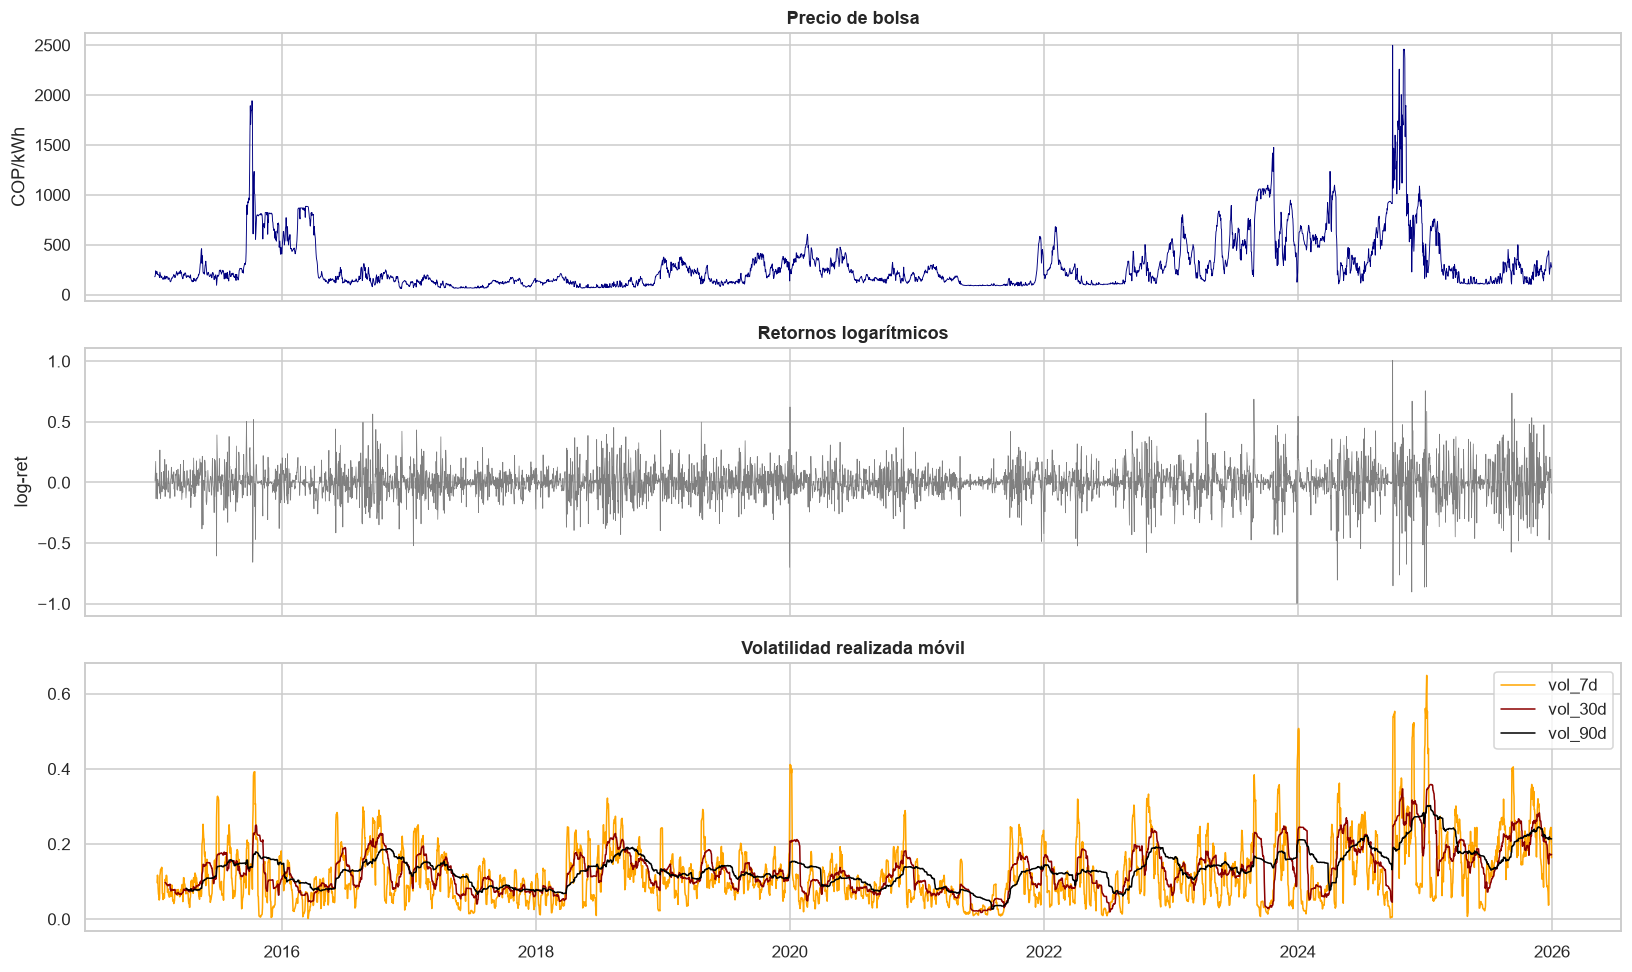

In [201]:
# ---- 9.1 Retornos y volatilidad realizada ----
pd_v = panel_d.set_index('fecha').copy()
pd_v['retorno'] = np.log(pd_v.precio_medio.replace(0, np.nan)).diff()
pd_v['vol_7d']  = pd_v.retorno.rolling(7).std()
pd_v['vol_30d'] = pd_v.retorno.rolling(30).std()
pd_v['vol_90d'] = pd_v.retorno.rolling(90).std()

fig, ax = plt.subplots(3, 1, figsize=(15, 9), sharex=True)
ax[0].plot(pd_v.index, pd_v.precio_medio, lw=.6, color='navy')
ax[0].set_title('Precio de bolsa'); ax[0].set_ylabel('COP/kWh')
ax[1].plot(pd_v.index, pd_v.retorno, lw=.5, color='gray')
ax[1].set_title('Retornos logarítmicos'); ax[1].set_ylabel('log-ret')
for c, col in [('vol_7d','orange'), ('vol_30d','darkred'), ('vol_90d','black')]:
    ax[2].plot(pd_v.index, pd_v[c], lw=1, color=col, label=c)
ax[2].set_title('Volatilidad realizada móvil'); ax[2].legend()
guardar_fig('volatilidad'); plt.show()

ARCH-LM (10 rezagos): LM=370.45  p=1.814e-73
  → Hay efectos ARCH: la volatilidad se agrupa.

Ljung-Box sobre retornos al cuadrado:


,lb_stat,lb_pvalue
5,522.041,0.000
10,680.529,0.000
20,776.809,0.000
30,824.548,0.000


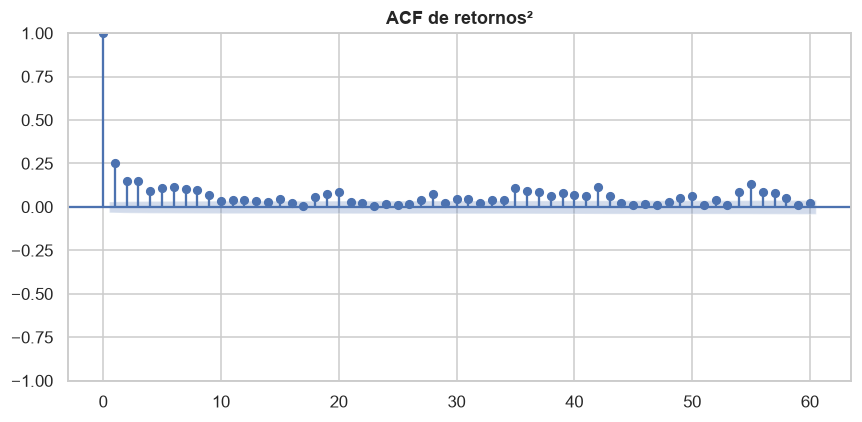


Implicación: si hay clustering, considerar (a) modelar en logaritmos, (b) intervalos de predicción por cuantiles o bootstrap en bloques, (c) incluir la volatilidad rezagada como feature en los modelos de ML.


In [202]:
# ---- 9.2 Pruebas de heterocedasticidad y agrupamiento ----
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox

ret = pd_v.retorno.dropna()

# ARCH-LM: ¿hay efectos ARCH en los retornos?
lm, p_lm, f, p_f = het_arch(ret, nlags=10)
print(f'ARCH-LM (10 rezagos): LM={lm:,.2f}  p={p_lm:.3e}')
print('  → ' + ('Hay efectos ARCH: la volatilidad se agrupa.' if p_lm < .05
                else 'No se detectan efectos ARCH.'))

# Ljung-Box sobre retornos al cuadrado
lb = acorr_ljungbox(ret**2, lags=[5,10,20,30], return_df=True)
print('\nLjung-Box sobre retornos al cuadrado:')
display(lb)

# Autocorrelación de retornos² — firma del clustering de volatilidad
fig, ax = plt.subplots(figsize=(8, 4))
plot_acf(ret**2, lags=60, ax=ax); ax.set_title('ACF de retornos²')
guardar_fig('acf_volatilidad'); plt.show()

print('\nImplicación: si hay clustering, considerar (a) modelar en logaritmos, '
      '(b) intervalos de predicción por cuantiles o bootstrap en bloques, '
      '(c) incluir la volatilidad rezagada como feature en los modelos de ML.')

,n,precio_medio,vol_media,retorno_std
regimen_enso,,,,
El Nino fuerte,426,678.812,0.135,0.138
El Nino,912,284.629,0.120,0.132
Neutral,1646,259.323,0.142,0.155
La Nina,1034,194.321,0.120,0.131


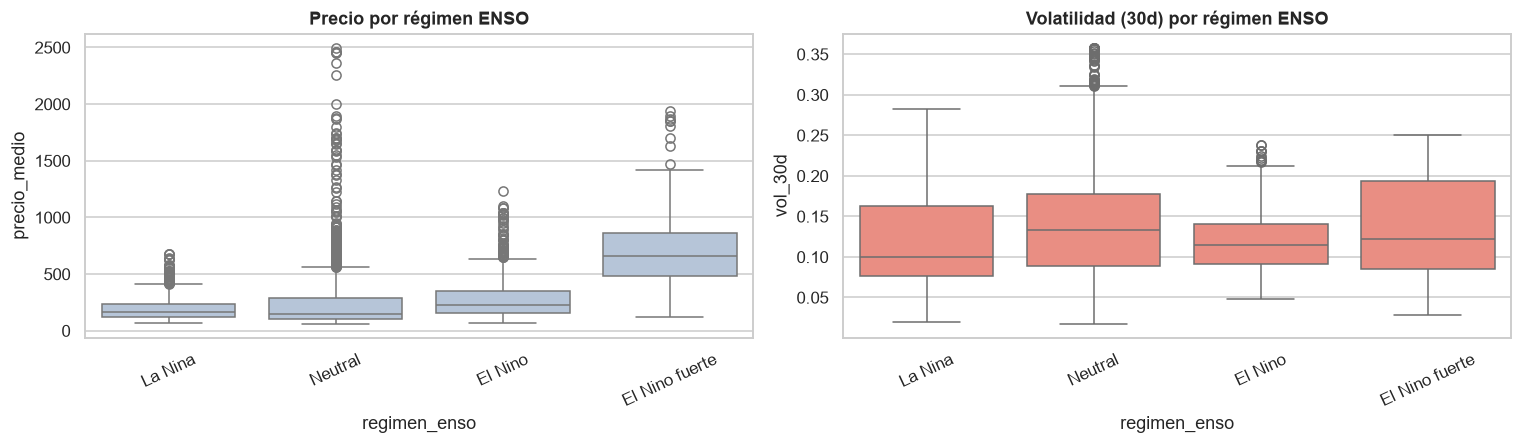

In [203]:
# ---- 9.3 Volatilidad por régimen ----
if 'regimen_enso' in panel_d.columns:
    vol_reg = pd_v  # ya contiene 'regimen_enso' (pd_v es copia de panel_d indexado por fecha)
    tabla_vol = vol_reg.groupby('regimen_enso').agg(
        n=('precio_medio','size'),
        precio_medio=('precio_medio','mean'),
        vol_media=('vol_30d','mean'),
        retorno_std=('retorno','std'),
    ).sort_values('precio_medio', ascending=False)
    display(tabla_vol)

    fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
    orden = ['La Nina fuerte','La Nina','Neutral','El Nino','El Nino fuerte']
    orden = [o for o in orden if o in vol_reg.regimen_enso.unique()]
    sns.boxplot(data=vol_reg.reset_index(), x='regimen_enso', y='precio_medio',
                order=orden, ax=ax[0], color='lightsteelblue')
    ax[0].set_title('Precio por régimen ENSO'); ax[0].tick_params(axis='x', rotation=25)
    sns.boxplot(data=vol_reg.reset_index(), x='regimen_enso', y='vol_30d',
                order=orden, ax=ax[1], color='salmon')
    ax[1].set_title('Volatilidad (30d) por régimen ENSO'); ax[1].tick_params(axis='x', rotation=25)
    guardar_fig('volatilidad_enso'); plt.show()

---
## 10. EDA por familia de métricas

Cada familia de variables se analiza en su propia lógica económica, no como una columna genérica más. El orden sigue la cadena causal del despacho por mérito: **demanda** define cuánta energía se necesita → **hidrología** define qué tan barata está el agua → **generación** define con qué se atiende → **oferta y mérito** define el precio → **escasez** define el techo → **contratos** define cuánto de eso realmente se paga a precio spot.

### 10.1 Demanda

La demanda es el lado que "consume" la curva de mérito: a mayor demanda, más arriba en el orden de mérito hay que subir, y más cara la última planta despachada. Interesa el nivel, pero sobre todo la **forma** de la curva (factor de carga, rampa) y su crecimiento tendencial.

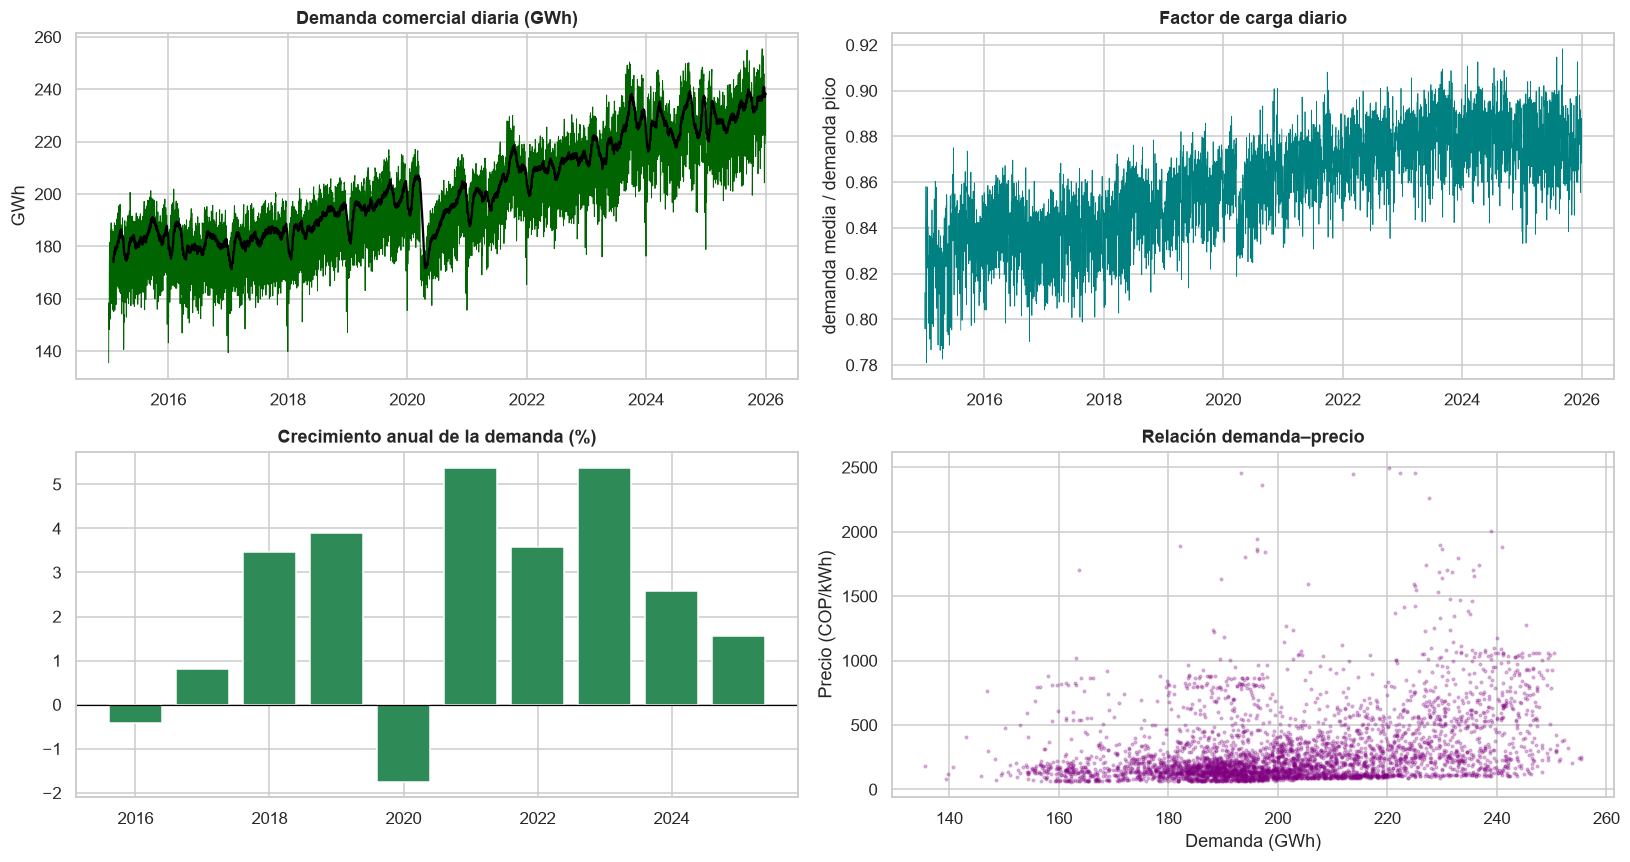

Crecimiento anual de la demanda:


,crecimiento_%
fecha,
2015-12-31,NaN
2016-12-31,-0.410
2017-12-31,0.820
2018-12-31,3.470
2019-12-31,3.900
2020-12-31,-1.740
2021-12-31,5.360
2022-12-31,3.570
2023-12-31,5.380



Correlación demanda–precio: Pearson=0.323 (p=3.14e-98) | Spearman=0.337
Ojo: una correlación baja NO significa que la demanda no importe. La relación es no lineal y condicional al estado hidrológico — con embalses llenos, más demanda no encarece; con embalses vacíos, sí.


In [204]:
fig, ax = plt.subplots(2, 2, figsize=(15, 8))

pdd = panel_d.set_index('fecha')
ax[0,0].plot(pdd.index, pdd.demanda_total/1e6, lw=.6, color='darkgreen')
ax[0,0].plot(pdd.index, (pdd.demanda_total/1e6).rolling(30).mean(), lw=1.5, color='black')
ax[0,0].set_title('Demanda comercial diaria (GWh)'); ax[0,0].set_ylabel('GWh')

ax[0,1].plot(pdd.index, pdd.factor_carga, lw=.5, color='teal')
ax[0,1].set_title('Factor de carga diario')
ax[0,1].set_ylabel('demanda media / demanda pico')

# Crecimiento interanual
crec = pdd.demanda_total.resample('YE').sum()
crec_pct = 100*crec.pct_change()
ax[1,0].bar(crec_pct.index.year, crec_pct.values, color='seagreen')
ax[1,0].axhline(0, color='black', lw=.8)
ax[1,0].set_title('Crecimiento anual de la demanda (%)')

ax[1,1].scatter(pdd.demanda_total/1e6, pdd.precio_medio, s=3, alpha=.25, color='purple')
ax[1,1].set_xlabel('Demanda (GWh)'); ax[1,1].set_ylabel('Precio (COP/kWh)')
ax[1,1].set_title('Relación demanda–precio')
guardar_fig('familia_demanda'); plt.show()

print('Crecimiento anual de la demanda:')
display(crec_pct.round(2).to_frame('crecimiento_%'))

from scipy import stats
d_ = pdd[['demanda_total','precio_medio']].dropna()
r_p = stats.pearsonr(d_.demanda_total, d_.precio_medio)
r_s = stats.spearmanr(d_.demanda_total, d_.precio_medio)
print(f'\nCorrelación demanda–precio: Pearson={r_p[0]:.3f} (p={r_p[1]:.2e}) | '
      f'Spearman={r_s[0]:.3f}')
print('Ojo: una correlación baja NO significa que la demanda no importe. La relación es '
      'no lineal y condicional al estado hidrológico — con embalses llenos, más demanda '
      'no encarece; con embalses vacíos, sí.')

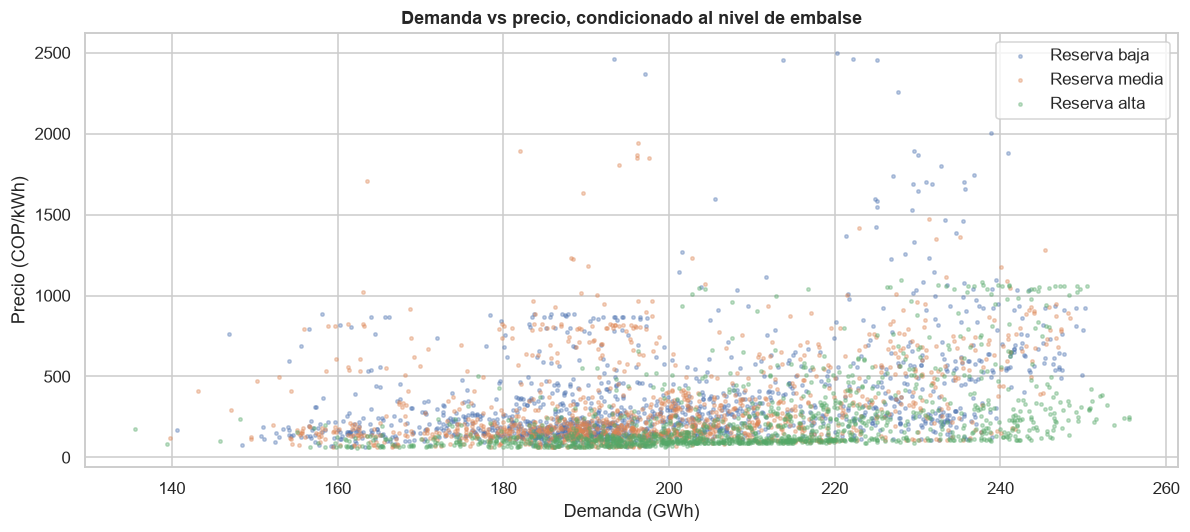

Correlación demanda–precio dentro de cada tercil de reserva:
  Reserva baja    r= 0.405  (n=1,340)
  Reserva media   r= 0.296  (n=1,339)
  Reserva alta    r= 0.461  (n=1,339)

Si la correlación cambia de signo o magnitud entre terciles, hay una interacción que los modelos lineales no capturan pero RF/XGBoost sí. Ese es un argumento directo a favor de los modelos no lineales de la tesis.


In [205]:
# ---- Relación no lineal: demanda vs precio condicionada a reserva ----
if 'reserva_pct' in panel_d.columns:
    tmp = panel_d.dropna(subset=['demanda_total','precio_medio','reserva_pct']).copy()
    tmp['tercil_reserva'] = pd.qcut(tmp.reserva_pct, 3,
                                    labels=['Reserva baja','Reserva media','Reserva alta'])

    fig, ax = plt.subplots(figsize=(11, 5))
    for lab, g in tmp.groupby('tercil_reserva', observed=True):
        ax.scatter(g.demanda_total/1e6, g.precio_medio, s=5, alpha=.35, label=lab)
    ax.set_xlabel('Demanda (GWh)'); ax.set_ylabel('Precio (COP/kWh)')
    ax.set_title('Demanda vs precio, condicionado al nivel de embalse')
    ax.legend()
    guardar_fig('demanda_precio_por_reserva'); plt.show()

    print('Correlación demanda–precio dentro de cada tercil de reserva:')
    for lab, g in tmp.groupby('tercil_reserva', observed=True):
        r = stats.pearsonr(g.demanda_total, g.precio_medio)[0]
        print(f'  {lab:<15} r={r:>6.3f}  (n={len(g):,})')
    print('\nSi la correlación cambia de signo o magnitud entre terciles, hay una '
          'interacción que los modelos lineales no capturan pero RF/XGBoost sí. '
          'Ese es un argumento directo a favor de los modelos no lineales de la tesis.')

### 10.2 Hidrología

El factor más determinante del precio en Colombia. Lo importante no es el aporte crudo sino la **anomalía**: cuánto se aparta el aporte de su media histórica para esa fecha. Un aporte de 100 GWh en abril es normal; el mismo aporte en enero es excepcional.

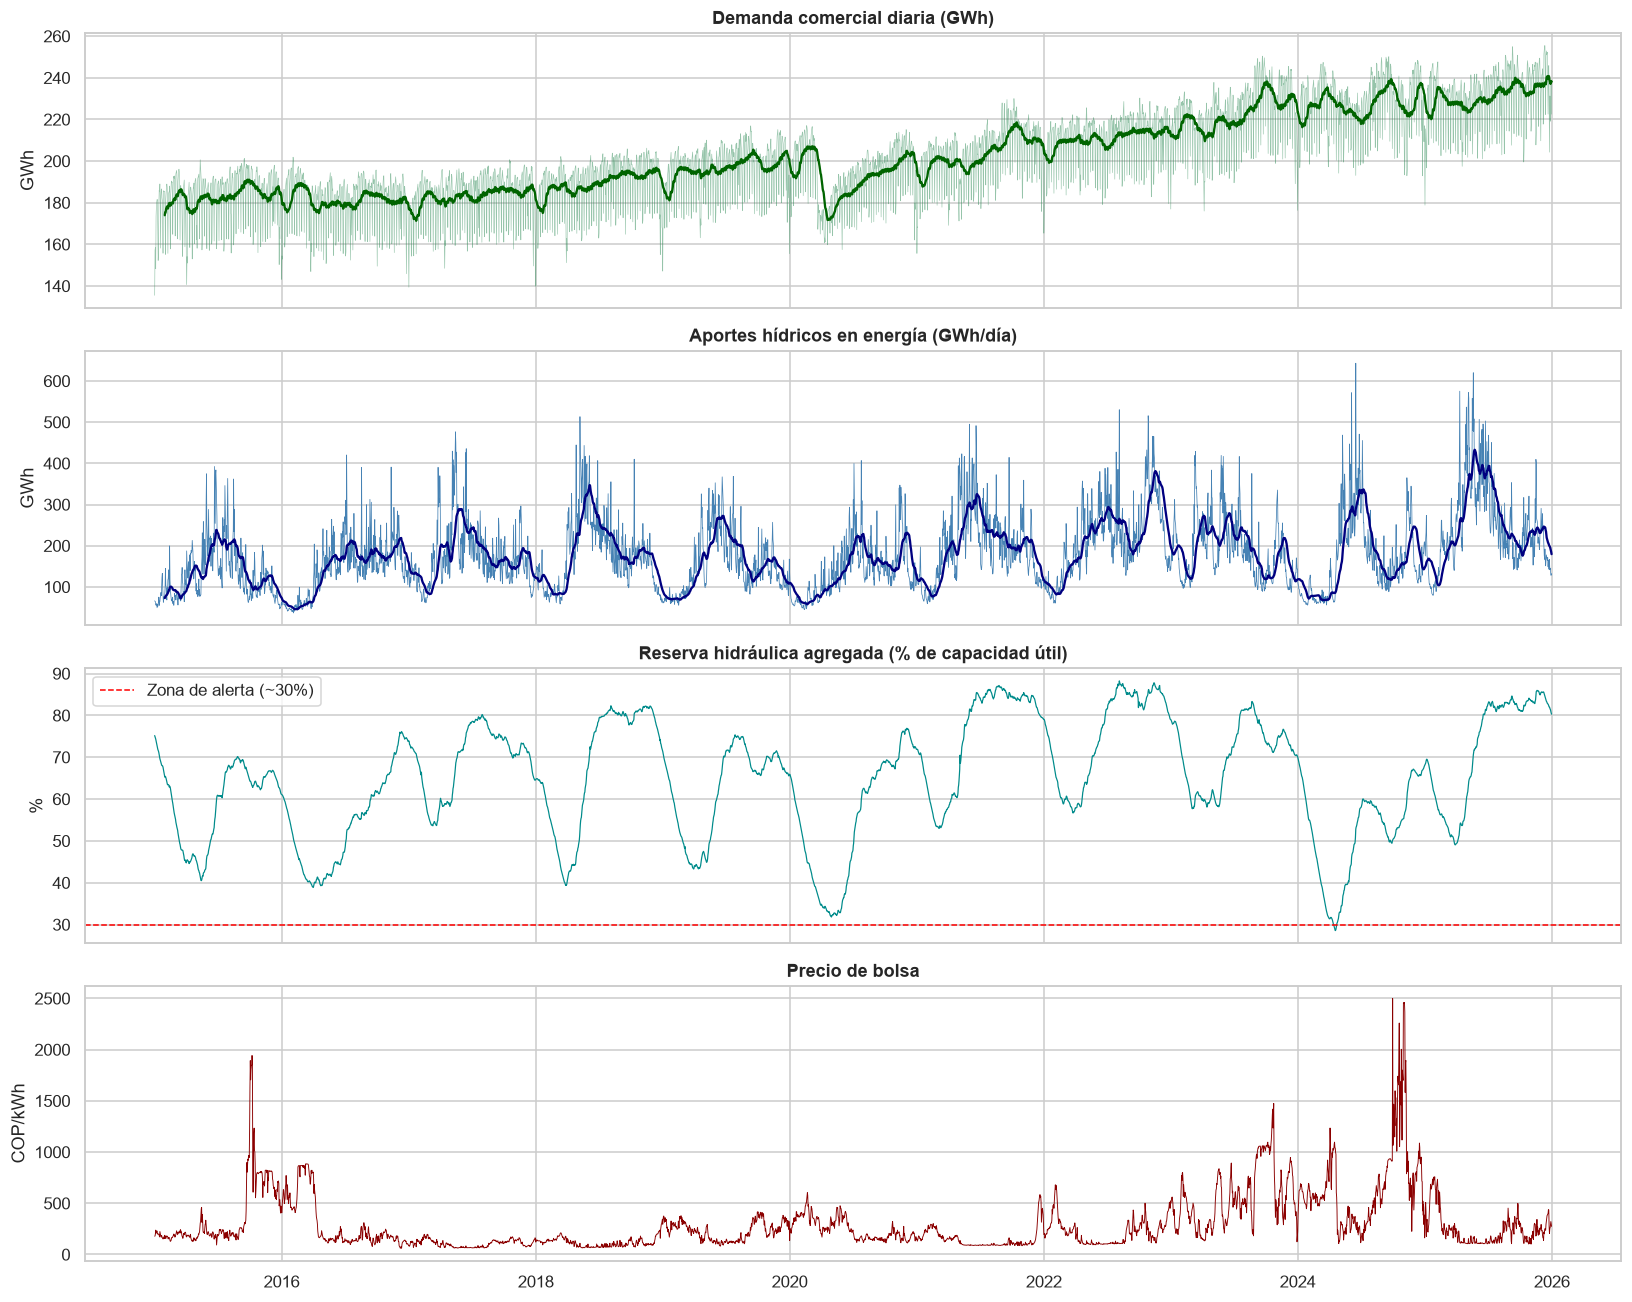

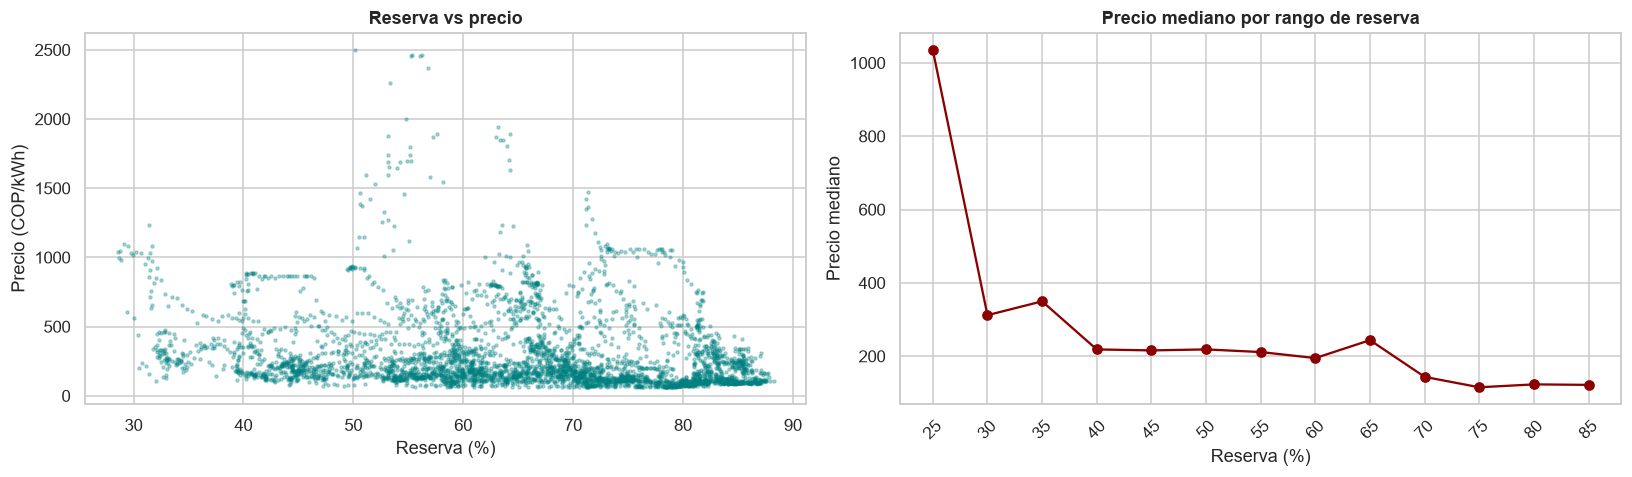

In [206]:
fig, ax = plt.subplots(4, 1, figsize=(15, 12), sharex=True)
pdd = panel_d.set_index('fecha')

ax[0].plot(pdd.index, pdd.demanda_total/1e6, lw=.4, color='seagreen', alpha=.5)
ax[0].plot(pdd.index, (pdd.demanda_total/1e6).rolling(30).mean(), lw=1.5, color='darkgreen')
ax[0].set_title('Demanda comercial diaria (GWh)'); ax[0].set_ylabel('GWh')

if 'aportes_energia' in pdd:
    ax[1].plot(pdd.index, pdd.aportes_energia/1e6, lw=.5, color='steelblue')
    ax[1].plot(pdd.index, (pdd.aportes_energia/1e6).rolling(30).mean(), lw=1.5, color='navy')
    ax[1].set_title('Aportes hídricos en energía (GWh/día)'); ax[1].set_ylabel('GWh')

if 'reserva_pct' in pdd:
    ax[2].plot(pdd.index, pdd.reserva_pct, lw=.8, color='darkcyan')
    ax[2].axhline(30, color='red', ls='--', lw=1, label='Zona de alerta (~30%)')
    ax[2].set_title('Reserva hidráulica agregada (% de capacidad útil)')
    ax[2].set_ylabel('%'); ax[2].legend()

ax[3].plot(pdd.index, pdd.precio_medio, lw=.6, color='darkred')
ax[3].set_title('Precio de bolsa'); ax[3].set_ylabel('COP/kWh')
guardar_fig('familia_hidrologia'); plt.show()

# Relación no lineal reserva → precio
if 'reserva_pct' in pdd:
    fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
    ax[0].scatter(pdd.reserva_pct, pdd.precio_medio, s=4, alpha=.3, color='teal')
    ax[0].set_xlabel('Reserva (%)'); ax[0].set_ylabel('Precio (COP/kWh)')
    ax[0].set_title('Reserva vs precio')

    binned = pdd.dropna(subset=['reserva_pct','precio_medio']).copy()
    binned['bin'] = pd.cut(binned.reserva_pct, bins=np.arange(0, 105, 5))
    med = binned.groupby('bin', observed=True).precio_medio.median()
    ax[1].plot(range(len(med)), med.values, 'o-', color='darkred')
    ax[1].set_xticks(range(len(med)))
    ax[1].set_xticklabels([str(i.left) for i in med.index], rotation=45)
    ax[1].set_xlabel('Reserva (%)'); ax[1].set_ylabel('Precio mediano')
    ax[1].set_title('Precio mediano por rango de reserva')
    guardar_fig('reserva_vs_precio'); plt.show()


Media histórica oficial incorporada.


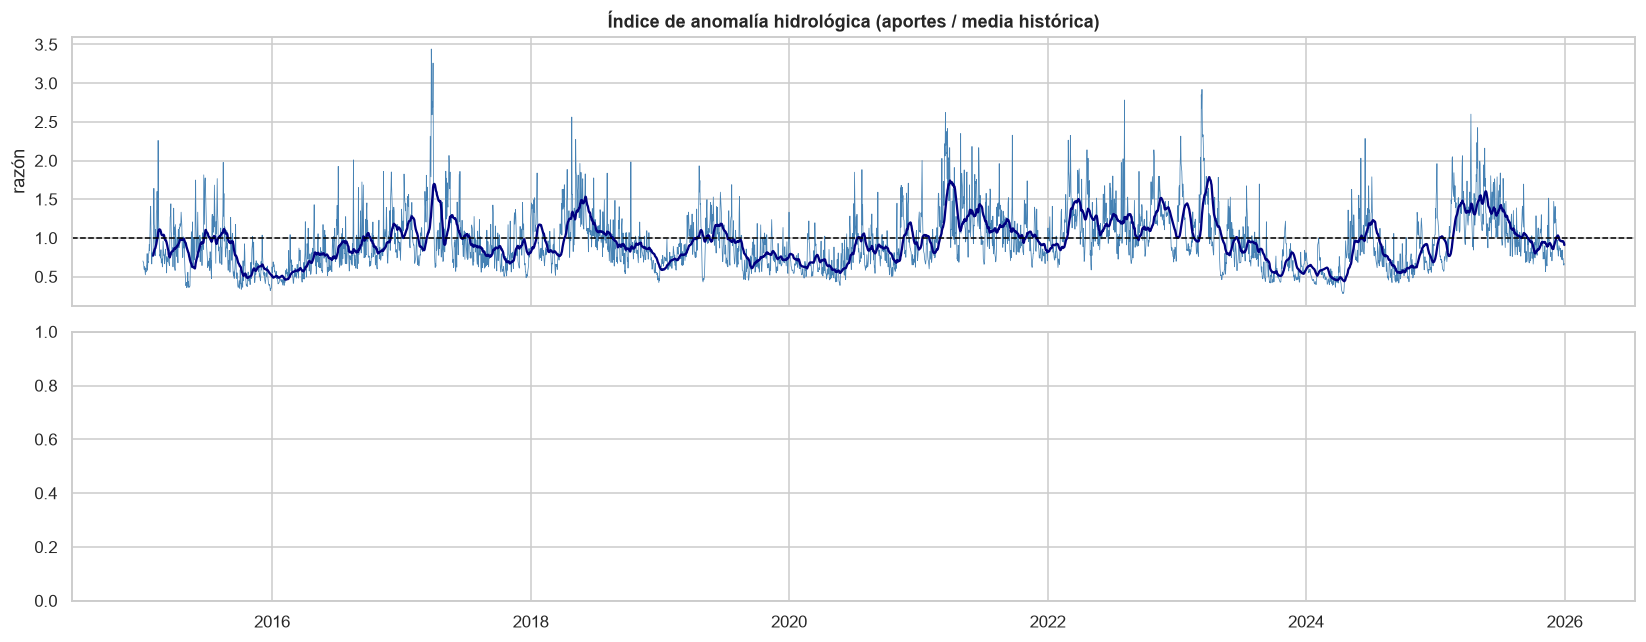

Correlación con el precio:
  Aportes crudos:    -0.301
  Índice anomalía:   -0.390

Si el índice de anomalía correlaciona más fuerte, confirma que normalizar por estacionalidad extrae mejor la señal — justifica preferirlo como feature.


In [207]:
# ---- Índice de anomalía hidrológica ----
# Requiere 'aportes_media_hist'. Si no está descargado, se construye una media
# histórica empírica por día del año con los propios datos.

# Evita columnas duplicadas (_x/_y) si la celda se re-ejecuta
panel_d = panel_d.drop(columns=['aportes_media_hist'], errors='ignore')

if 'aportes_media_hist' in descargados:
    amh = descargados['aportes_media_hist'].copy()
    # Normalizar nombres de columna (varían según la API)
    col_f = [c for c in amh.columns if 'fecha' in c.lower() or 'date' in c.lower()][0]
    col_v = [c for c in amh.columns if 'value' in c.lower() or 'valor' in c.lower()][0]
    amh = amh[[col_f, col_v]].rename(columns={col_f:'fecha', col_v:'aportes_media_hist'})
    amh['fecha'] = pd.to_datetime(amh.fecha)
    # La API de XM entrega 'Value' como texto (dtype object) -> convertir a numérico (kWh)
    amh['aportes_media_hist'] = pd.to_numeric(amh.aportes_media_hist, errors='coerce')
    amh = amh.drop_duplicates('fecha')
    panel_d = panel_d.merge(amh, on='fecha', how='left')
    print('Media histórica oficial incorporada.')
else:
    # Alternativa: media empírica por día del año (excluye el año evaluado para evitar sesgo)
    panel_d['aportes_media_hist'] = panel_d.groupby('dia_anio').aportes_energia.transform('mean')
    print('Media histórica construida empíricamente por día del año.')

panel_d['anomalia_hidro'] = panel_d.aportes_energia / panel_d.aportes_media_hist

fig, ax = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
ax[0].plot(panel_d.fecha, panel_d.anomalia_hidro, lw=.5, color='steelblue')
ax[0].plot(panel_d.fecha, panel_d.anomalia_hidro.rolling(30).mean(), lw=1.5, color='navy')
ax[0].axhline(1, color='black', ls='--', lw=1)
ax[0].set_title('Índice de anomalía hidrológica (aportes / media histórica)')
ax[0].set_ylabel('razón')
guardar_fig('anomalia_hidrologica'); plt.show()

comp = panel_d[['anomalia_hidro','aportes_energia','precio_medio']].dropna()
print(f'Correlación con el precio:')
print(f'  Aportes crudos:   {comp.aportes_energia.corr(comp.precio_medio):>7.3f}')
print(f'  Índice anomalía:  {comp.anomalia_hidro.corr(comp.precio_medio):>7.3f}')
print('\nSi el índice de anomalía correlaciona más fuerte, confirma que normalizar por '
      'estacionalidad extrae mejor la señal — justifica preferirlo como feature.')

### 10.3 Generación y mezcla tecnológica

La composición de la generación es el mecanismo de transmisión entre hidrología y precio: cuando el agua escasea, entra la térmica, que oferta más caro. Esta sección construye la serie de participación por tecnología cruzando *generación por recurso* con la tabla maestra de plantas.

In [208]:
# ---- Mezcla de generación por tecnología ----
mezcla = None
if 'gen_por_recurso' in descargados and mapeo_recursos is not None:
    g = descargados['gen_por_recurso'].copy()
    col_rec = [c for c in g.columns
               if any(k in c.lower() for k in ('code', 'codigo', 'recurso'))][0]
    col_f   = [c for c in g.columns if 'fecha' in c.lower() or 'date' in c.lower()][0]
    cols_h  = [c for c in g.columns if 'hour' in c.lower()]

    g['fecha'] = pd.to_datetime(g[col_f])
    g['gen_dia'] = g[cols_h].sum(axis=1) if cols_h else g['Value']

    g = g.merge(mapeo_recursos[['codigo','familia','es_fncer']],
                left_on=col_rec, right_on='codigo', how='left')
    g['familia'] = g.familia.fillna('OTRA')

    mezcla = g.pivot_table(index='fecha', columns='familia',
                           values='gen_dia', aggfunc='sum').fillna(0)
    mezcla_pct = 100 * mezcla.div(mezcla.sum(axis=1), axis=0)

    fig, ax = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
    mezcla_pct.plot.area(ax=ax[0], linewidth=0, cmap='tab20')
    ax[0].set_title('Participación de la generación por tecnología (%)')
    ax[0].set_ylabel('%'); ax[0].legend(loc='upper left', ncol=4, fontsize=8)
    ax[1].plot(panel_d.fecha, panel_d.precio_medio, lw=.6, color='darkred')
    ax[1].set_title('Precio de bolsa')
    guardar_fig('mezcla_generacion'); plt.show()

    # Incorporar al panel
    for col in mezcla_pct.columns:
        panel_d[f'pct_{col.lower()}'] = panel_d.fecha.map(mezcla_pct[col])
    panel_d['pct_fncer'] = panel_d[[c for c in panel_d.columns
                                    if c in ['pct_eolica','pct_solar','pct_biomasa']]].sum(axis=1)
    display(mezcla_pct.resample('YE').mean().round(2))
else:
    print('Pendiente: descargar "gen_por_recurso" y el Listado de Recursos.')
    print('Alternativa disponible ahora: usar emisiones de CO2 eq/kWh como proxy continuo '
          'de la participación térmica (ver celda siguiente).')

Pendiente: descargar "gen_por_recurso" y el Listado de Recursos.
Alternativa disponible ahora: usar emisiones de CO2 eq/kWh como proxy continuo de la participación térmica (ver celda siguiente).


In [209]:
# ---- Proxy alternativo: intensidad de carbono ----
# gCO2e/kWh es esencialmente un índice continuo de "qué tan térmico" está el sistema.
if 'emisiones_co2_kwh' in descargados:
    e = descargados['emisiones_co2_kwh'].copy()
    col_f  = [c for c in e.columns if 'fecha' in c.lower() or 'date' in c.lower()][0]
    cols_h = [c for c in e.columns if 'hour' in c.lower()]
    e['fecha'] = pd.to_datetime(e[col_f])
    e['intensidad_co2'] = e[cols_h].mean(axis=1) if cols_h else e['Value']
    e = e.groupby('fecha').intensidad_co2.mean().reset_index()

    panel_d = panel_d.merge(e, on='fecha', how='left')

    fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
    ax[0].plot(panel_d.fecha, panel_d.intensidad_co2, lw=.6, color='dimgray')
    ax[0].set_title('Intensidad de carbono del sistema (gCO2e/kWh)')
    ax[1].scatter(panel_d.intensidad_co2, panel_d.precio_medio, s=4, alpha=.3, color='maroon')
    ax[1].set_xlabel('gCO2e/kWh'); ax[1].set_ylabel('Precio')
    ax[1].set_title('Intensidad de carbono vs precio')
    guardar_fig('intensidad_carbono'); plt.show()

    c = panel_d[['intensidad_co2','precio_medio']].dropna()
    print(f'Correlación intensidad CO2 – precio: {c.intensidad_co2.corr(c.precio_medio):.3f}')
    print('Una correlación alta confirma el mecanismo: precios altos = sistema térmico.')

### 10.4 Oferta y orden de mérito

Aquí están las variables **ex-ante** de mayor valor predictivo. El precio de bolsa *es* el resultado de cruzar la curva de oferta con la demanda; tener las ofertas es tener casi el resultado.

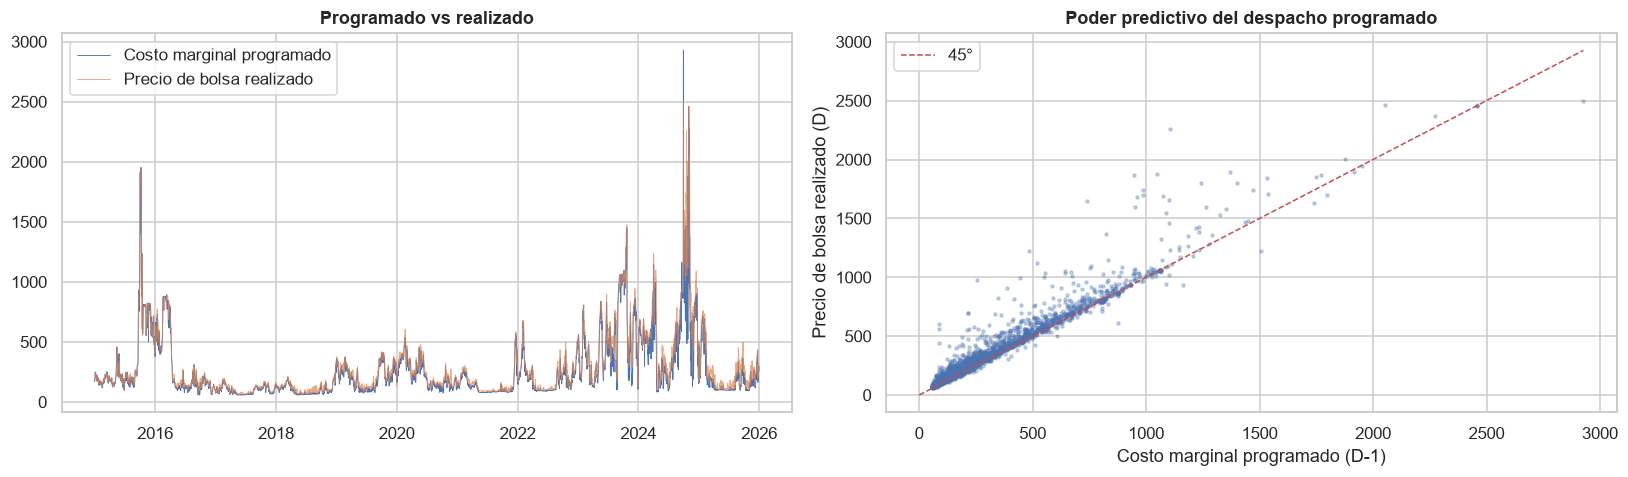

Correlación: 0.9708   R² implícito: 0.9425
Error medio (realizado − programado): 34.03 COP/kWh
MAE del despacho programado como pronóstico ingenuo: 36.53

⚠️ DECISIÓN METODOLÓGICA: si esta variable explica casi todo, incluirla puede aplanar las diferencias entre SARIMAX/RF/XGBoost/LSTM y volver trivial la comparación que es el objeto de la tesis. Recomendación: correr DOS escenarios (con y sin esta variable) y reportar ambos. El escenario sin ella mide la capacidad de los modelos de aprender la estructura del mercado; el escenario con ella mide el desempeño operativo máximo alcanzable.


In [210]:
# ---- Costo marginal del despacho programado vs precio realizado ----
if 'costo_marginal_prog' in descargados:
    cm = descargados['costo_marginal_prog'].copy()
    col_f  = [c for c in cm.columns if 'fecha' in c.lower() or 'date' in c.lower()][0]
    cols_h = [c for c in cm.columns if 'hour' in c.lower()]
    cm['fecha'] = pd.to_datetime(cm[col_f])
    cm['costo_marginal'] = cm[cols_h].mean(axis=1) if cols_h else cm['Value']
    cm = cm.groupby('fecha').costo_marginal.mean().reset_index()

    panel_d = panel_d.drop(columns=['costo_marginal'], errors='ignore')
    panel_d = panel_d.merge(cm, on='fecha', how='left')
    cmp_ = panel_d[['fecha','costo_marginal','precio_medio']].dropna()

    fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
    ax[0].plot(cmp_.fecha, cmp_.costo_marginal, lw=.6, label='Costo marginal programado')
    ax[0].plot(cmp_.fecha, cmp_.precio_medio, lw=.6, label='Precio de bolsa realizado', alpha=.7)
    ax[0].legend(); ax[0].set_title('Programado vs realizado')

    ax[1].scatter(cmp_.costo_marginal, cmp_.precio_medio, s=4, alpha=.3)
    lims = [0, max(cmp_.costo_marginal.max(), cmp_.precio_medio.max())]
    ax[1].plot(lims, lims, 'r--', lw=1, label='45°')
    ax[1].set_xlabel('Costo marginal programado (D-1)')
    ax[1].set_ylabel('Precio de bolsa realizado (D)')
    ax[1].legend(); ax[1].set_title('Poder predictivo del despacho programado')
    guardar_fig('costo_marginal'); plt.show()

    r = cmp_.costo_marginal.corr(cmp_.precio_medio)
    err = cmp_.precio_medio - cmp_.costo_marginal
    print(f'Correlación: {r:.4f}   R² implícito: {r**2:.4f}')
    print(f'Error medio (realizado − programado): {err.mean():,.2f} COP/kWh')
    print(f'MAE del despacho programado como pronóstico ingenuo: {err.abs().mean():,.2f}')
    print('\n⚠️ DECISIÓN METODOLÓGICA: si esta variable explica casi todo, incluirla puede '
          'aplanar las diferencias entre SARIMAX/RF/XGBoost/LSTM y volver trivial la '
          'comparación que es el objeto de la tesis. Recomendación: correr DOS escenarios '
          '(con y sin esta variable) y reportar ambos. El escenario sin ella mide la '
          'capacidad de los modelos de aprender la estructura del mercado; el escenario '
          'con ella mide el desempeño operativo máximo alcanzable.')

Filas para 2024-02-15: 68
24 columnas de hora encontradas
68 recursos con oferta válida esa hora


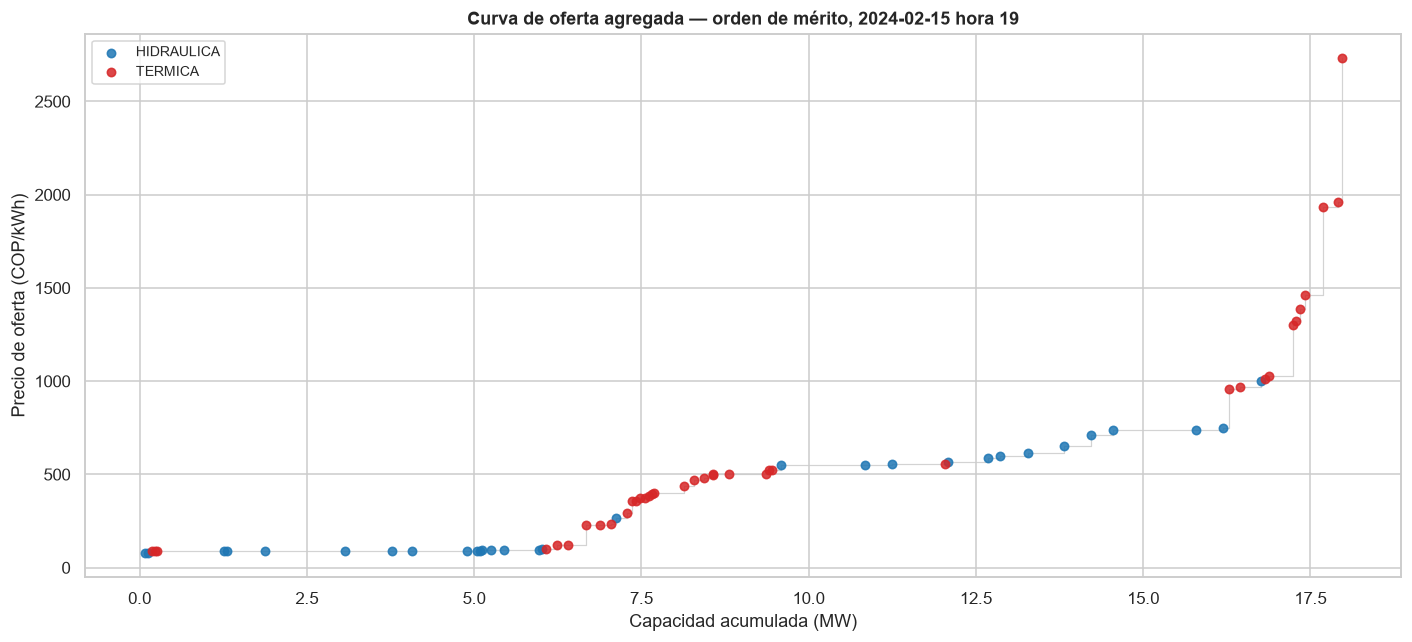

Composición por familia, en orden de entrada al mérito:


,n_plantas,precio_min,precio_max,mw_total
familia,,,,
HIDRAULICA,30,81.000,999.000,12.237
TERMICA,38,87.000,"2,730.427",5.728


In [211]:
# ---- Curva de oferta agregada (orden de mérito) — versión corregida para pydataxm ----
if 'precio_oferta_desp' in descargados and 'disp_declarada' in descargados:
    fecha_ej = '2024-02-15'
    hora_ej = 19

    po = descargados['precio_oferta_desp'].copy()

    # Estructura estándar de pydataxm: Id, Values_code, Values_Hour01..24, Date
    col_rec_po = 'Values_code' if 'Values_code' in po.columns else \
                 [c for c in po.columns if 'code' in c.lower()][0]
    col_f_po = [c for c in po.columns if c.lower() == 'date'] or \
               [c for c in po.columns if 'date' in c.lower() or 'fecha' in c.lower()]
    col_f_po = col_f_po[0]

    po['fecha'] = pd.to_datetime(po[col_f_po])

    dia = po[po.fecha == fecha_ej]
    print(f'Filas para {fecha_ej}: {len(dia)}')

    if len(dia):
        cols_hora = sorted([c for c in dia.columns if c.startswith('Values_Hour')])
        print(f'{len(cols_hora)} columnas de hora encontradas')

        col_hora_ej = cols_hora[hora_ej] if hora_ej < len(cols_hora) else cols_hora[0]
        dia = dia.assign(precio_oferta=pd.to_numeric(dia[col_hora_ej], errors='coerce'))

        curva = dia[[col_rec_po, 'precio_oferta']].dropna().sort_values('precio_oferta')
        print(f'{len(curva)} recursos con oferta válida esa hora')

        if mapeo_recursos is not None and 'familia' in mapeo_recursos.columns:
            curva = curva.merge(mapeo_recursos[['codigo', 'familia', 'capacidad_kw']],
                                left_on=col_rec_po, right_on='codigo', how='left')
            curva['familia'] = curva['familia'].fillna('SIN CLASIFICAR')
            curva['cap_acum'] = pd.to_numeric(curva.capacidad_kw, errors='coerce').fillna(0).cumsum()/1000

            COLORES_FAMILIA = {
                'HIDRAULICA':'#1f77b4', 'TERMICA':'#d62728', 'EOLICA':'#2ca02c',
                'SOLAR':'#ff7f0e', 'COGENERADOR':'#9467bd', 'SIN CLASIFICAR':'#7f7f7f',
            }

            fig, ax = plt.subplots(figsize=(13, 6))
            for fam, g in curva.groupby('familia'):
                ax.scatter(g.cap_acum, g.precio_oferta, s=30,
                          color=COLORES_FAMILIA.get(fam, '#7f7f7f'), label=fam, alpha=.85)
            ax.step(curva.cap_acum, curva.precio_oferta, where='post', color='lightgray', lw=.8, zorder=0)
            ax.set_xlabel('Capacidad acumulada (MW)'); ax.set_ylabel('Precio de oferta (COP/kWh)')
            ax.set_title(f'Curva de oferta agregada — orden de mérito, {fecha_ej} hora {hora_ej}')
            ax.legend(fontsize=9)
            guardar_fig('curva_merito'); plt.show()

            print('Composición por familia, en orden de entrada al mérito:')
            display(curva.groupby('familia').agg(
                n_plantas=('codigo','count'), precio_min=('precio_oferta','min'),
                precio_max=('precio_oferta','max'),
                mw_total=('capacidad_kw', lambda s: pd.to_numeric(s, errors='coerce').sum()/1000)
            ).sort_values('precio_min'))
        else:
            print('mapeo_recursos no tiene columna "familia" — corre antes la celda de FAMILIAS.')
    else:
        print(f'No hay datos para {fecha_ej}. Fechas disponibles: '
              f'{po.fecha.min()} a {po.fecha.max()}')
else:
    print('Pendiente: descargar precio_oferta_desp y disp_declarada.')

### 10.5 Precio de escasez — el techo del mercado

El precio de escasez actúa como **techo**, no como piso. Cuando el precio de bolsa se aproxima a él, el comportamiento del mercado cambia cualitativamente. La Resolución CREG 101 066 de 2024 separó el precio único en PEI/PES por tecnología, lo que constituye un quiebre estructural que el modelo debe reconocer.

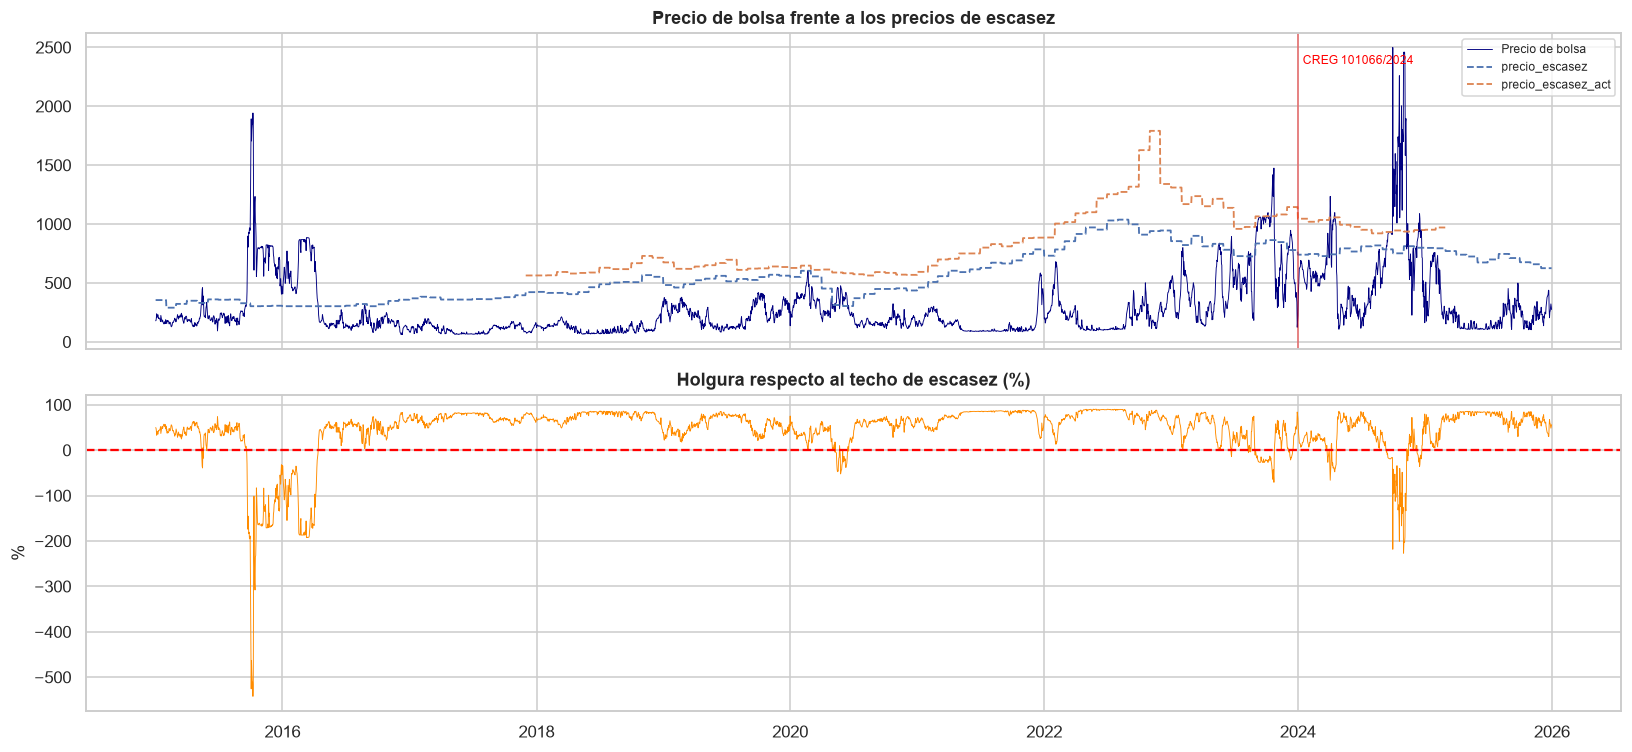

Días con precio ≥95% del precio de escasez: 464 (11.55% de los días con dato)
Estos días representan censura efectiva de la distribución: el precio no puede subir más. Un modelo que no lo sepa predecirá valores imposibles. Considerar truncar las predicciones al techo vigente en cada fecha.


In [212]:
cols_esc = [c for c in ['precio_escasez','precio_escasez_act','precio_marg_escasez']
            if c in descargados]

if cols_esc:
    for v in cols_esc:
        d = descargados[v].copy()
        col_f = [c for c in d.columns if 'fecha' in c.lower() or 'date' in c.lower()][0]
        col_v = [c for c in d.columns if 'value' in c.lower() or 'valor' in c.lower()][0]
        d = d[[col_f, col_v]].rename(columns={col_f:'fecha', col_v:v})
        d['fecha'] = pd.to_datetime(d.fecha)
        panel_d = panel_d.merge(d.groupby('fecha')[v].mean().reset_index(), on='fecha', how='left')

    ref = cols_esc[0]
    fig, ax = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
    ax[0].plot(panel_d.fecha, panel_d.precio_medio, lw=.6, label='Precio de bolsa', color='navy')
    for v in cols_esc:
        ax[0].plot(panel_d.fecha, panel_d[v], lw=1.2, ls='--', label=v)
    ax[0].axvline(pd.Timestamp('2024-01-01'), color='red', lw=1, alpha=.5)
    ax[0].text(pd.Timestamp('2024-01-15'), ax[0].get_ylim()[1]*.9,
               'CREG 101066/2024', fontsize=8, color='red')
    ax[0].legend(fontsize=8); ax[0].set_title('Precio de bolsa frente a los precios de escasez')

    panel_d['margen_escasez'] = 100*(panel_d[ref] - panel_d.precio_medio)/panel_d[ref]
    ax[1].plot(panel_d.fecha, panel_d.margen_escasez, lw=.6, color='darkorange')
    ax[1].axhline(0, color='red', ls='--')
    ax[1].set_title('Holgura respecto al techo de escasez (%)'); ax[1].set_ylabel('%')
    guardar_fig('precio_escasez'); plt.show()

    n_trunc = (panel_d.precio_medio >= panel_d[ref]*0.95).sum()
    print(f'Días con precio ≥95% del precio de escasez: {n_trunc} '
          f'({100*n_trunc/panel_d[ref].notna().sum():.2f}% de los días con dato)')
    print('Estos días representan censura efectiva de la distribución: el precio no puede '
          'subir más. Un modelo que no lo sepa predecirá valores imposibles. Considerar '
          'truncar las predicciones al techo vigente en cada fecha.')
else:
    print('Pendiente: descargar las series de precio de escasez.')

---
## 11. Análisis regional y espacial


La hipótesis a evaluar: **¿aporta la distribución espacial información predictiva más allá de los agregados nacionales?**

In [213]:
# ---- 11.1 Hidrología por río ----
if 'aportes_por_rio' in descargados:
    ar = descargados['aportes_por_rio'].copy()
    col_rio = [c for c in ar.columns if 'rio' in c.lower() or 'name' in c.lower()][0]
    col_f   = [c for c in ar.columns if 'fecha' in c.lower() or 'date' in c.lower()][0]
    col_v   = [c for c in ar.columns if 'value' in c.lower()][0]
    ar['fecha'] = pd.to_datetime(ar[col_f])

    top_rios = ar.groupby(col_rio)[col_v].sum().nlargest(15)
    print('15 ríos con mayor aporte energético acumulado:')
    display((top_rios/1e9).round(2).to_frame('TWh acumulados'))

    piv_rio = ar[ar[col_rio].isin(top_rios.index)].pivot_table(
        index='fecha', columns=col_rio, values=col_v, aggfunc='sum')

    fig, ax = plt.subplots(figsize=(14, 5))
    (piv_rio.rolling(30).mean()/1e6).plot(ax=ax, lw=.8, cmap='tab20')
    ax.set_title('Aportes por río (media móvil 30d, GWh)')
    ax.legend(fontsize=7, ncol=3); ax.set_ylabel('GWh')
    guardar_fig('aportes_por_rio'); plt.show()

    # Correlación de cada río con el precio
    corr_rios = {}
    for rio in piv_rio.columns:
        s = piv_rio[rio].reindex(panel_d.set_index('fecha').index)
        corr_rios[rio] = s.corr(panel_d.set_index('fecha').precio_medio)
    cr = pd.Series(corr_rios).sort_values()
    fig, ax = plt.subplots(figsize=(10, 5))
    cr.plot.barh(ax=ax, color=['darkred' if v<0 else 'steelblue' for v in cr])
    ax.set_title('Correlación de los aportes de cada río con el precio de bolsa')
    ax.axvline(0, color='black', lw=.8)
    guardar_fig('correlacion_rios'); plt.show()
    print('Los ríos con correlación más negativa son los sistemas hidráulicos que más '
          'presionan el precio a la baja. No todos pesan igual.')
else:
    print('Pendiente: descargar aportes_por_rio.')

Pendiente: descargar aportes_por_rio.


In [214]:
# ---- 11.2 Concentración espacial de la reserva (índice HHI) ----
# Hipótesis: a igual reserva agregada, mayor concentración = mayor riesgo de precio.
if 'volumen_por_embalse' in descargados:
    ve = descargados['volumen_por_embalse'].copy()
    col_emb = [c for c in ve.columns if 'embalse' in c.lower() or 'name' in c.lower()][0]
    col_f   = [c for c in ve.columns if 'fecha' in c.lower() or 'date' in c.lower()][0]
    col_v   = [c for c in ve.columns if 'value' in c.lower()][0]
    ve['fecha'] = pd.to_datetime(ve[col_f])

    piv_emb = ve.pivot_table(index='fecha', columns=col_emb, values=col_v, aggfunc='sum')
    share = piv_emb.div(piv_emb.sum(axis=1), axis=0)

    hhi = (share**2).sum(axis=1)             # Herfindahl-Hirschman
    entropia = -(share*np.log(share.replace(0,np.nan))).sum(axis=1)

    conc = pd.DataFrame({'hhi_embalses': hhi, 'entropia_embalses': entropia})
    panel_d = panel_d.merge(conc.reset_index().rename(columns={col_f:'fecha'}),
                            on='fecha', how='left')

    fig, ax = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
    ax[0].plot(panel_d.fecha, panel_d.hhi_embalses, lw=.7, color='purple')
    ax[0].set_title('Concentración de la reserva entre embalses (HHI)')
    ax[1].plot(panel_d.fecha, panel_d.precio_medio, lw=.6, color='darkred')
    ax[1].set_title('Precio de bolsa')
    guardar_fig('concentracion_embalses'); plt.show()

    sub = panel_d[['hhi_embalses','reserva_pct','precio_medio']].dropna()
    print('Correlaciones con el precio:')
    print(f'  Reserva agregada (%):  {sub.reserva_pct.corr(sub.precio_medio):>7.3f}')
    print(f'  Concentración (HHI):   {sub.hhi_embalses.corr(sub.precio_medio):>7.3f}')

    # ¿Aporta el HHI más allá de la reserva agregada? Correlación parcial.
    import statsmodels.api as sm
    r_y = sm.OLS(sub.precio_medio, sm.add_constant(sub.reserva_pct)).fit().resid
    r_x = sm.OLS(sub.hhi_embalses, sm.add_constant(sub.reserva_pct)).fit().resid
    print(f'\n  Correlación PARCIAL del HHI con el precio, controlando por reserva '
          f'agregada: {np.corrcoef(r_x, r_y)[0,1]:.3f}')
    print('  Si es materialmente distinta de cero, la concentración espacial aporta '
          'información propia y debe incluirse como feature.')
else:
    print('Pendiente: descargar volumen_por_embalse.')

Pendiente: descargar volumen_por_embalse.


In [215]:
# ---- 11.3 Demanda por operador de red / región ----
if 'demanda_por_or' in descargados:
    dor = descargados['demanda_por_or'].copy()
    col_ag = [c for c in dor.columns if 'agente' in c.lower() or 'code' in c.lower()][0]
    col_f  = [c for c in dor.columns if 'fecha' in c.lower() or 'date' in c.lower()][0]
    cols_h = [c for c in dor.columns if 'hour' in c.lower()]
    dor['fecha'] = pd.to_datetime(dor[col_f])
    dor['dem_dia'] = dor[cols_h].sum(axis=1)

    top_or = dor.groupby(col_ag).dem_dia.sum().nlargest(12)
    piv_or = dor[dor[col_ag].isin(top_or.index)].pivot_table(
        index='fecha', columns=col_ag, values='dem_dia', aggfunc='sum')

    fig, ax = plt.subplots(1, 2, figsize=(16, 4.5))
    (piv_or.resample('ME').sum()/1e6).plot(ax=ax[0], lw=.9, cmap='tab20')
    ax[0].set_title('Demanda mensual por operador de red (GWh)')
    ax[0].legend(fontsize=6, ncol=2)

    crec_or = 100*(piv_or.resample('YE').sum().iloc[-1]/piv_or.resample('YE').sum().iloc[0] - 1)
    crec_or.sort_values().plot.barh(ax=ax[1], color='teal')
    ax[1].set_title('Crecimiento acumulado de la demanda por OR (%)')
    guardar_fig('demanda_regional'); plt.show()

    print('El crecimiento heterogéneo entre regiones importa porque cambia la ubicación '
          'geográfica de la carga, lo que interactúa con las restricciones de transmisión.')
else:
    print('Pendiente: descargar demanda_por_or.')

Pendiente: descargar demanda_por_or.


In [216]:
# ---- 11.4 Demanda no atendida por área ----
if 'demanda_no_atendida' in descargados:
    dna = descargados['demanda_no_atendida'].copy()
    col_area = [c for c in dna.columns if 'area' in c.lower() or 'name' in c.lower()][0]
    col_f    = [c for c in dna.columns if 'fecha' in c.lower() or 'date' in c.lower()][0]
    col_v    = [c for c in dna.columns if 'value' in c.lower()][0]
    dna['fecha'] = pd.to_datetime(dna[col_f])

    por_area = dna.groupby(col_area)[col_v].sum().nlargest(15)
    fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
    (por_area/1e6).plot.barh(ax=ax[0], color='indianred')
    ax[0].set_title('Demanda no atendida acumulada por área (GWh)')

    total_dia = dna.groupby('fecha')[col_v].sum()
    ax[1].plot(total_dia.index, total_dia.values/1e3, lw=.6, color='darkred')
    ax[1].set_title('Demanda no atendida total diaria (MWh)')
    guardar_fig('demanda_no_atendida'); plt.show()

    panel_d = panel_d.merge(total_dia.reset_index().rename(
        columns={col_f:'fecha', col_v:'dem_no_atendida'}), on='fecha', how='left')
else:
    print('Pendiente: descargar demanda_no_atendida.')

Pendiente: descargar demanda_no_atendida.


familia,COGENERADOR,EOLICA,HIDRAULICA,SOLAR,TERMICA,TOTAL
region,,,,,,
ANTIOQUIA,0.000,0.000,6.600,0.000,0.400,7.000
CUNDINAMARCA,0.000,0.000,2.200,0.400,0.200,2.800
ATLÁNTICO,0.000,0.000,0.000,1.000,1.600,2.700
SANTANDER,0.000,0.000,1.400,0.000,0.500,2.000
VALLE DEL CAUCA,0.100,0.000,0.600,0.200,0.500,1.400
BOYACÁ,0.000,0.000,1.000,0.000,0.400,1.400
CÓRDOBA,0.000,0.000,0.300,0.300,0.600,1.200
BOLÍVAR,0.000,0.000,0.000,0.100,0.900,1.000
HUILA,0.000,0.000,0.900,0.000,0.000,1.000


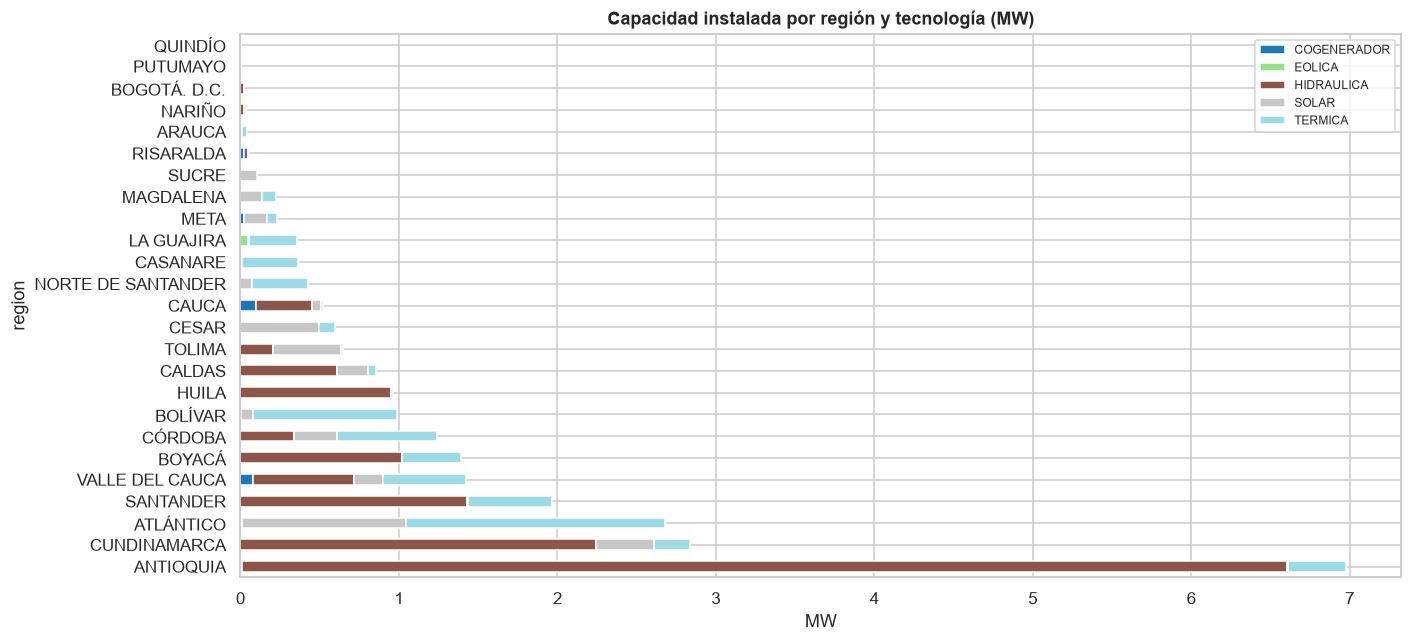

In [231]:
# ---- 11.5 Distribución geográfica de la capacidad instalada ----
if mapeo_recursos is not None and 'region' in mapeo_recursos.columns:
    geo = mapeo_recursos.copy()
    geo['capacidad_mw'] = pd.to_numeric(geo.capacidad_kw, errors='coerce')/1000

    tabla_geo = geo.pivot_table(index='region', columns='familia',
                                values='capacidad_mw', aggfunc='sum').fillna(0)
    tabla_geo['TOTAL'] = tabla_geo.sum(axis=1)
    tabla_geo = tabla_geo.sort_values('TOTAL', ascending=False)
    display(tabla_geo.round(1))

    fig, ax = plt.subplots(figsize=(13, 6))
    tabla_geo.drop(columns='TOTAL').plot.barh(stacked=True, ax=ax, cmap='tab20')
    ax.set_title('Capacidad instalada por región y tecnología (MW)')
    ax.set_xlabel('MW'); ax.legend(fontsize=8)
    guardar_fig('capacidad_por_region'); plt.show()

   
else:
    print('Pendiente: el Listado de Recursos con columna de región/departamento.')

---
## 12. Análisis multivariado

Cómo se relacionan las variables entre sí y con el precio. Se usan **tres medidas complementarias** porque cada una captura algo distinto:

- **Pearson** — relación lineal
- **Spearman** — relación monótona (robusta a no linealidad y outliers)
- **Información mutua** — cualquier dependencia estadística, incluida la no monótona

Un trabajo que solo mira Pearson —como hace la tesis de referencia— descarta variables que sí importan pero cuya relación no es lineal.

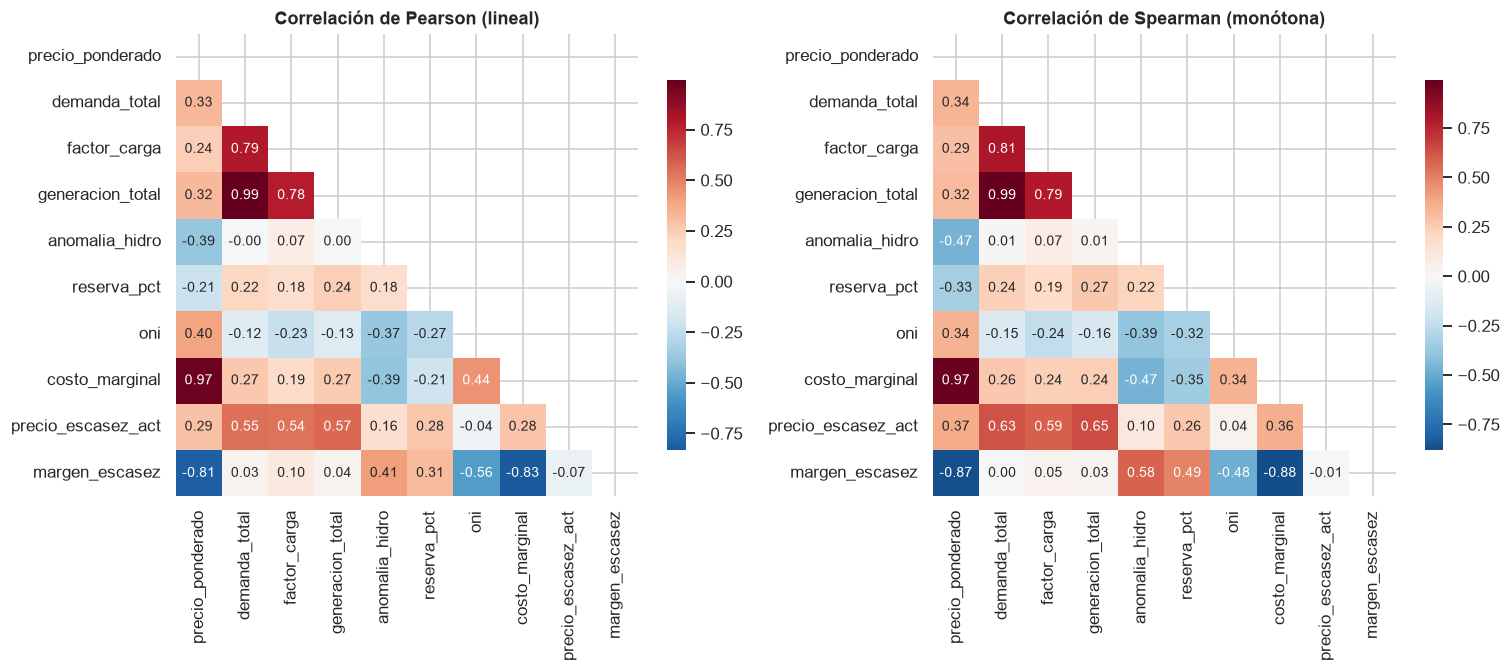

In [232]:
# ---- 12.1b Matriz de correlación reducida — solo variables sustantivas ----

# Se elimina la redundancia dentro de cada familia, quedándose con UN representante:
# - Precio: precio_ponderado (el relevante para la evaluación económica, ya vimos
#   que difiere del promedio simple porque pondera por demanda)
# - Demanda: demanda_total (descarta max/min, que están casi perfectamente
#   correlacionados con el total — ya lo confirma el heatmap original)
# - Hidrología: anomalia_hidro en vez de aportes_energia + aportes_media_hist por
#   separado (ya demostraste que el índice normalizado correlaciona más fuerte)
# - Reserva: reserva_pct en vez de volumen_util + capacidad_util (reserva_pct
#   YA ES esa razón, mostrar los tres es triplicar la misma información)
# - Escasez: precio_escasez_act en vez de las dos variantes (correlación entre
#   ellas ~1 en tu propio heatmap, son casi la misma serie)

VARIABLES_CLAVE = [
    'precio_ponderado',
    'demanda_total',
    'factor_carga',
    'generacion_total',
    'anomalia_hidro',
    'reserva_pct',
    'oni',
    'costo_marginal',
    'precio_escasez_act',
    'margen_escasez',
]
VARIABLES_CLAVE = [v for v in VARIABLES_CLAVE if v in panel_d.columns]

corr_p_reducida = panel_d[VARIABLES_CLAVE].corr(method='pearson')
corr_s_reducida = panel_d[VARIABLES_CLAVE].corr(method='spearman')

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
mask = np.triu(np.ones_like(corr_p_reducida, dtype=bool))

sns.heatmap(corr_p_reducida, mask=mask, cmap='RdBu_r', center=0, ax=ax[0],
            annot=True, fmt='.2f', square=True, cbar_kws={'shrink': .75},
            annot_kws={'size': 9})
ax[0].set_title('Correlación de Pearson (lineal)')

sns.heatmap(corr_s_reducida, mask=mask, cmap='RdBu_r', center=0, ax=ax[1],
            annot=True, fmt='.2f', square=True, cbar_kws={'shrink': .75},
            annot_kws={'size': 9})
ax[1].set_title('Correlación de Spearman (monótona)')

guardar_fig('matrices_correlacion_reducida'); plt.show()

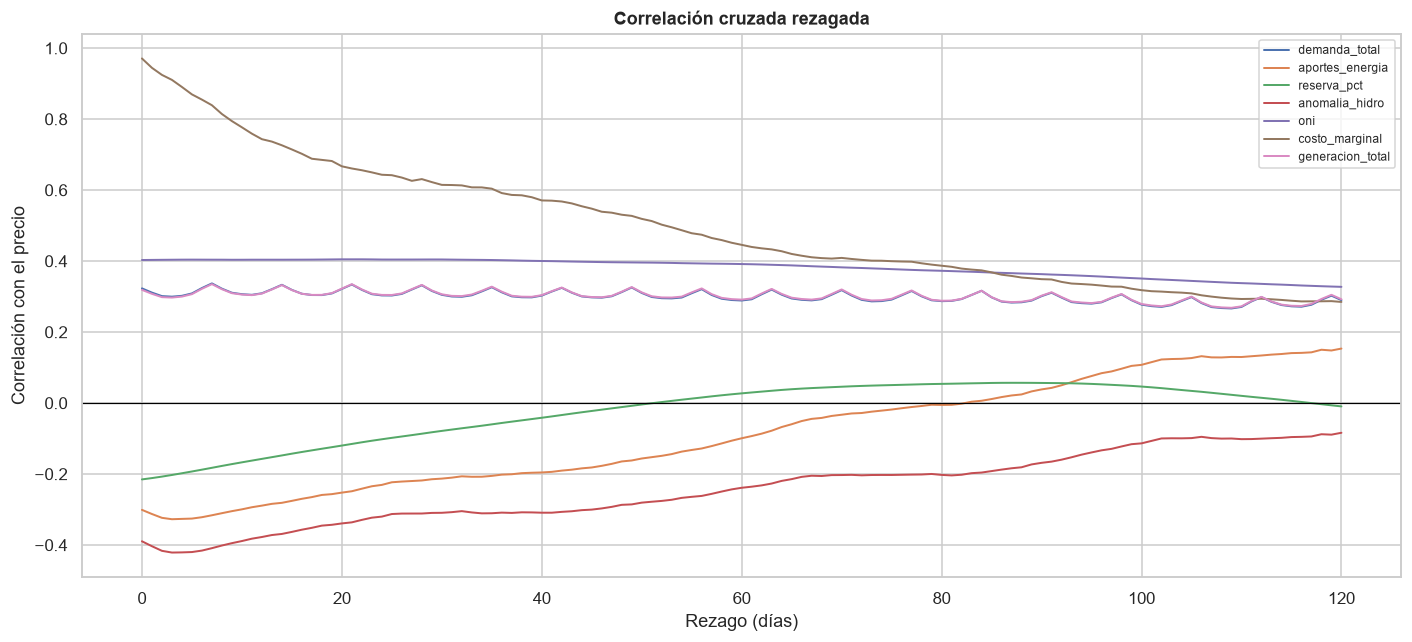

,lag_optimo,corr_en_optimo,corr_lag0
demanda_total,7.000,0.337,0.323
aportes_energia,3.000,-0.327,-0.301
reserva_pct,0.000,-0.215,-0.215
anomalia_hidro,3.000,-0.421,-0.390
oni,22.000,0.405,0.403
costo_marginal,0.000,0.971,0.971
generacion_total,7.000,0.335,0.319


El rezago óptimo indica con cuánta anticipación cada variable "anuncia" el precio. Rezagos largos en hidrología reflejan que el efecto del agua se acumula: no es el aporte de hoy sino el de las últimas semanas lo que fija el precio de hoy.


In [220]:
# ---- 12.3 Correlaciones cruzadas rezagadas ----
def corr_rezagada(x, y, max_lag=90):
    """Correlación de x rezagada k días contra y (k>0: x precede a y)."""
    out = {}
    for k in range(0, max_lag+1):
        out[k] = x.shift(k).corr(y)
    return pd.Series(out)

pdi = panel_d.set_index('fecha')
vars_lag = [c for c in ['demanda_total','aportes_energia','reserva_pct','anomalia_hidro',
                        'oni','intensidad_co2','costo_marginal','generacion_total']
            if c in pdi.columns]

fig, ax = plt.subplots(figsize=(13, 6))
tabla_lag = {}
for v in vars_lag:
    cc = corr_rezagada(pdi[v], pdi.precio_medio, 120)
    ax.plot(cc.index, cc.values, lw=1.3, label=v)
    tabla_lag[v] = {'lag_optimo': int(cc.abs().idxmax()),
                    'corr_en_optimo': cc[cc.abs().idxmax()],
                    'corr_lag0': cc[0]}
ax.axhline(0, color='black', lw=.8)
ax.set_xlabel('Rezago (días)'); ax.set_ylabel('Correlación con el precio')
ax.set_title('Correlación cruzada rezagada')
ax.legend(fontsize=8)
guardar_fig('correlacion_rezagada'); plt.show()

display(pd.DataFrame(tabla_lag).T.round(3))
print('El rezago óptimo indica con cuánta anticipación cada variable "anuncia" el precio. '
      'Rezagos largos en hidrología reflejan que el efecto del agua se acumula: no es el '
      'aporte de hoy sino el de las últimas semanas lo que fija el precio de hoy.')

In [221]:
# ---- 12.4 Multicolinealidad (VIF) ----
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

cand = [c for c in ['demanda_total','generacion_total','reserva_pct','aportes_energia',
                    'anomalia_hidro','oni','factor_carga','intensidad_co2']
        if c in panel_d.columns]
X = panel_d[cand].dropna()

if len(X) > 50 and len(cand) > 1:
    X_ = sm.add_constant(X)
    vif = pd.DataFrame({
        'variable': X_.columns,
        'VIF': [variance_inflation_factor(X_.values, i) for i in range(X_.shape[1])]
    }).query("variable != 'const'").sort_values('VIF', ascending=False)
    display(vif)
    print('VIF > 10 indica multicolinealidad severa. Importa para SARIMAX (coeficientes '
          'inestables) pero mucho menos para RF/XGBoost, que toleran predictores '
          'correlacionados. Documentar esta asimetría es parte del análisis comparativo.')

,variable,VIF
1,demanda_total,106.335
2,generacion_total,100.573
7,factor_carga,2.957
5,anomalia_hidro,2.911
4,aportes_energia,2.875
6,oni,1.293
3,reserva_pct,1.266


VIF > 10 indica multicolinealidad severa. Importa para SARIMAX (coeficientes inestables) pero mucho menos para RF/XGBoost, que toleran predictores correlacionados. Documentar esta asimetría es parte del análisis comparativo.


---
## 13. Regímenes y quiebres estructurales

Un modelo entrenado en un régimen puede fallar en otro. Esta sección identifica si la serie tiene regímenes distinguibles y dónde están los quiebres — información crítica para diseñar la partición de la **validación walk-forward**.

In [234]:
# ---- Complemento: ANOVA clásico (F) entre los 4 regímenes ENSO ----
grupos_enso = [g.precio_medio.dropna().values for _, g in panel_d.groupby('regimen_enso')]
f_stat_enso, p_f_enso = stats.f_oneway(*grupos_enso)

print('=== ANOVA clásico — entre los 4 regímenes ENSO ===')
print(f'F={f_stat_enso:.2f}  p={p_f_enso:.3e}  → '
      f'{"diferencia significativa" if p_f_enso < 0.05 else "sin diferencia significativa"}')

print('\n=== Comparación de conclusiones ===')
print(f'{"Prueba":<25}{"Estadístico":>15}{"p-valor":>15}{"¿Significativo?":>20}')
print(f'{"Kruskal-Wallis H":<25}{"900.9":>15}{"5.751e-195":>15}{"Sí":>20}')
print(f'{"ANOVA F":<25}{f_stat_enso:>15.1f}{p_f_enso:>15.3e}'
      f'{"Sí" if p_f_enso<0.05 else "No":>20}')

=== ANOVA clásico — entre los 4 regímenes ENSO ===
F=433.59  p=5.383e-244  → diferencia significativa

=== Comparación de conclusiones ===
Prueba                       Estadístico        p-valor     ¿Significativo?
Kruskal-Wallis H                   900.9     5.751e-195                  Sí
ANOVA F                            433.6     5.383e-244                  Sí


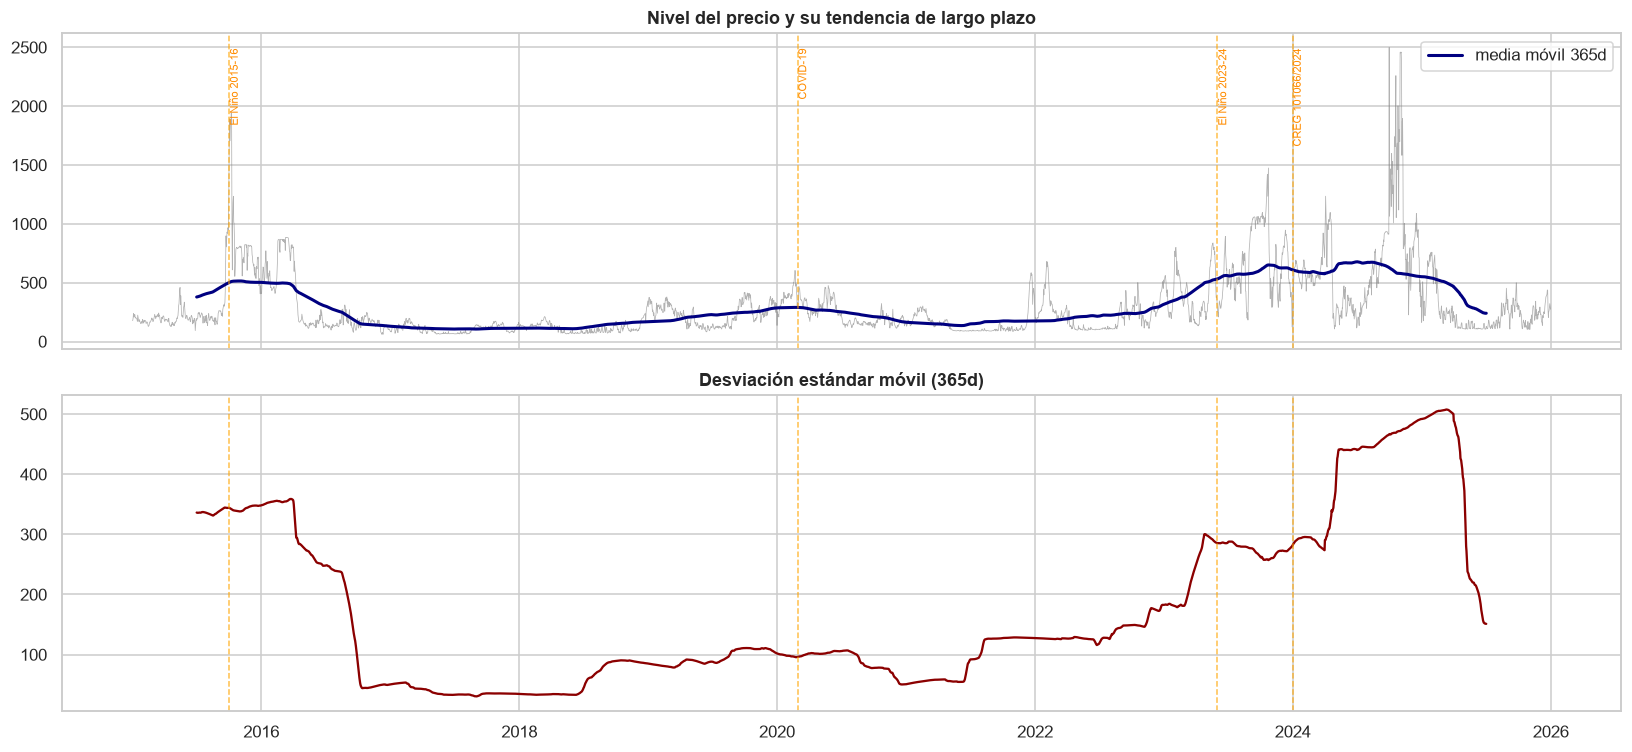

In [235]:
# ---- 13.2 Detección de quiebres estructurales ----
serie_q = panel_d.set_index('fecha').precio_medio.dropna()

# Media y desviación móviles anuales
fig, ax = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
ax[0].plot(serie_q.index, serie_q, lw=.5, color='gray', alpha=.6)
ax[0].plot(serie_q.index, serie_q.rolling(365, center=True).mean(),
           lw=2, color='navy', label='media móvil 365d')
ax[0].legend(); ax[0].set_title('Nivel del precio y su tendencia de largo plazo')

ax[1].plot(serie_q.index, serie_q.rolling(365, center=True).std(),
           lw=1.5, color='darkred')
ax[1].set_title('Desviación estándar móvil (365d)')

# Eventos regulatorios y climáticos conocidos
eventos = {
    '2015-10-01': 'El Niño 2015-16',
    
    '2020-03-01': 'COVID-19',
    '2023-06-01': 'El Niño 2023-24',
    '2024-01-01': 'CREG 101066/2024',
}
for f, lab in eventos.items():
    for a in ax:
        a.axvline(pd.Timestamp(f), color='orange', ls='--', lw=1, alpha=.7)
    ax[0].text(pd.Timestamp(f), ax[0].get_ylim()[1]*.95, lab,
               rotation=90, fontsize=7, va='top', color='darkorange')
guardar_fig('quiebres_estructurales'); plt.show()